# **Data Understanding**

#### 1. Initial data exploration
#### 2. Data quality assessment
        - Duplicates
        - Missing Values
        - Logical Inconsistencies
#### 3. Numerical features analysis
#### 4. Categorical features analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from collections import Counter
from scipy import stats
from statsmodels.stats.multitest import multipletests
from matplotlib.ticker import ScalarFormatter

In [2]:
# Percorso robusto: funziona sia lanciando il notebook dalla cartella "notebooks/"
# sia dalla root del progetto, senza dover dipendere dalla working directory corrente.
candidate_paths = [
    Path("../data/DM1_game_dataset.csv"),
    Path("data/DM1_game_dataset.csv"),
]
file_name = next((p for p in candidate_paths if p.exists()), candidate_paths[0])

df = pd.read_csv(file_name)
df.head()

,BGGId,Name,Description,YearPublished,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,...,Rank:childrensgames,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating
0,140386,Assassin's Creed: Arena,game description publisherin assassins creed a...,2014,1.8333,2.0512,2,4,8.0,213.0,...,21926,0,0,0,0,0,0,0,0,Low
1,344114,Bag of Chips,bag chip party game face crucial choice score ...,2021,1.0000,1.2256,2,5,8.0,36.0,...,21926,0,0,0,0,0,0,0,0,Medium
2,319196,Gùgōng: Deluxe Big Box,big box contain component gugravegng deluxe ed...,2020,3.6667,3.8190,1,5,NaN,NaN,...,21926,0,0,0,0,0,0,0,0,High
3,11404,LetterFlip,publisherthe reveal game secret wordsletterfli...,2004,1.3077,1.4216,2,2,7.0,NaN,...,21926,0,0,0,0,0,0,0,0,Low
4,281020,Treasures of Cibola,rescue mayan treasure easy task ...,2019,1.5000,1.6230,2,4,NaN,7.0,...,21926,0,0,0,0,0,0,0,0,Medium


### **1. Initial data exploration**

In [3]:
df.info()       

<class 'pandas.DataFrame'>
RangeIndex: 21925 entries, 0 to 21924
Data columns (total 46 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   BGGId                21925 non-null  int64  
 1   Name                 21925 non-null  str    
 2   Description          21924 non-null  str    
 3   YearPublished        21925 non-null  int64  
 4   GameWeight           21925 non-null  float64
 5   ComWeight            21925 non-null  float64
 6   MinPlayers           21925 non-null  int64  
 7   MaxPlayers           21925 non-null  int64  
 8   ComAgeRec            16395 non-null  float64
 9   LanguageEase         16034 non-null  float64
 10  BestPlayers          21925 non-null  int64  
 11  GoodPlayers          21925 non-null  str    
 12  NumOwned             21925 non-null  int64  
 13  NumWant              21925 non-null  int64  
 14  NumWish              21925 non-null  int64  
 15  NumWeightVotes       21925 non-null  int64  
 1

In [4]:
df.head()       

,BGGId,Name,Description,YearPublished,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,...,Rank:childrensgames,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating
0,140386,Assassin's Creed: Arena,game description publisherin assassins creed a...,2014,1.8333,2.0512,2,4,8.0,213.0,...,21926,0,0,0,0,0,0,0,0,Low
1,344114,Bag of Chips,bag chip party game face crucial choice score ...,2021,1.0000,1.2256,2,5,8.0,36.0,...,21926,0,0,0,0,0,0,0,0,Medium
2,319196,Gùgōng: Deluxe Big Box,big box contain component gugravegng deluxe ed...,2020,3.6667,3.8190,1,5,NaN,NaN,...,21926,0,0,0,0,0,0,0,0,High
3,11404,LetterFlip,publisherthe reveal game secret wordsletterfli...,2004,1.3077,1.4216,2,2,7.0,NaN,...,21926,0,0,0,0,0,0,0,0,Low
4,281020,Treasures of Cibola,rescue mayan treasure easy task ...,2019,1.5000,1.6230,2,4,NaN,7.0,...,21926,0,0,0,0,0,0,0,0,Medium


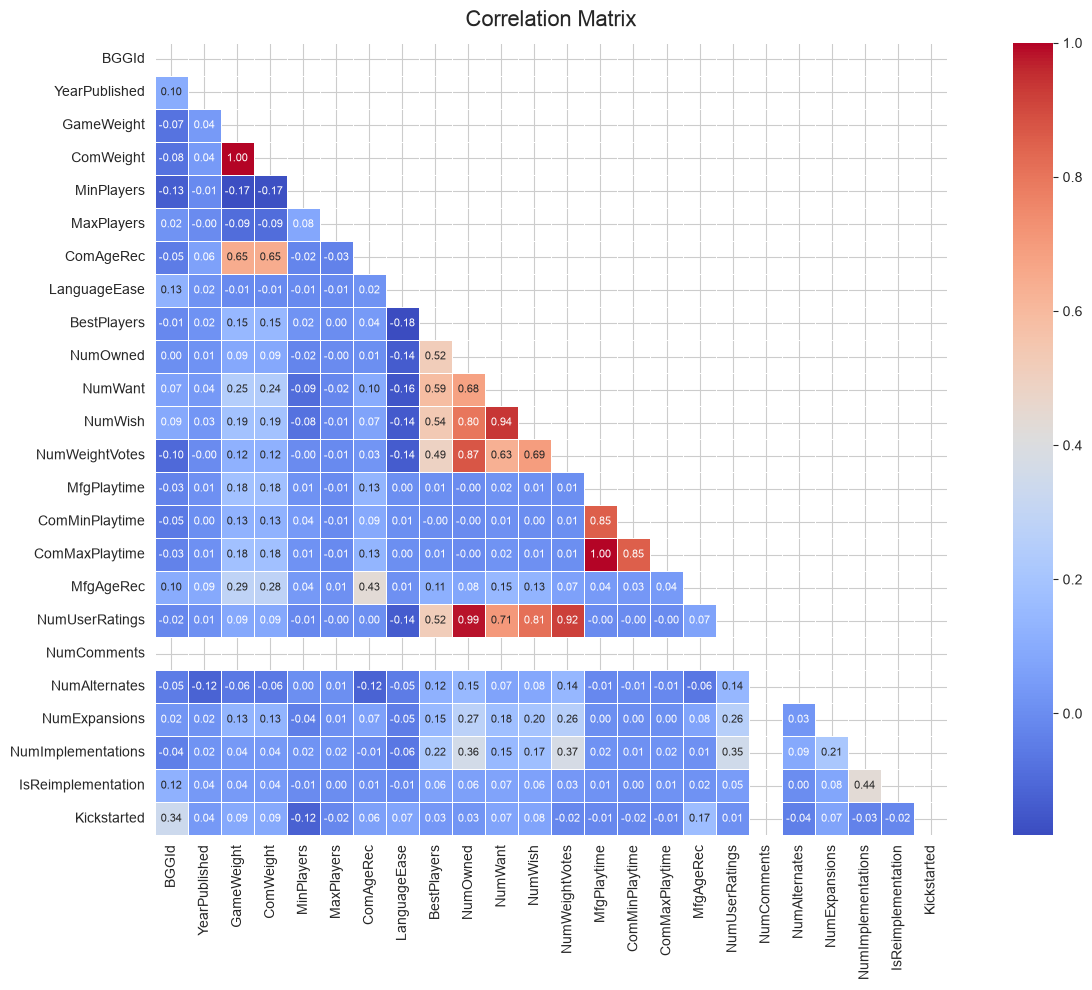

In [5]:
# 1. Select all numeric columns
numeric_df = df.select_dtypes(include="number")

# 2. Automatically exclude ALL columns starting with Cat: or Rank:
cols_to_drop = [c for c in numeric_df.columns if c.startswith("Cat:") or c.startswith("Rank:")]
numeric_df = numeric_df.drop(columns=cols_to_drop)

# 3. Correlation matrix
corr_matrix = numeric_df.corr()

# 4. Upper triangle mask
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 5. Plot the heatmap
plt.figure(figsize=(14, 10))
sns.set_style("whitegrid")

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=True,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 8}
)

plt.title("Correlation Matrix", fontsize=16, pad=12)
plt.tight_layout()
plt.show()

### **2. Data quality assessment**

### Duplicates

In [6]:
df['BGGId'].duplicated().sum()      # no games with the same ID

np.int64(0)

In [7]:
df['Name'].duplicated().sum()       # 404 duplicated names (bc some games migh have different versions)

np.int64(404)

In [8]:
n_same_descrip = df['Description'].duplicated().sum()
print(f"Total number of games with the same description (repetitions): {n_same_descrip}\n")

same_descrip_df = df[df['Description'].duplicated(keep=False)].copy()

same_descrip_sorted = same_descrip_df.sort_values(by='Description')

print("Games grouped by identical description:\n")
# Iterate over each group of games sharing the same description
for description, group in same_descrip_sorted.groupby('Description'):
    # Calculate the number of games in this specific group
    game_count = len(group)
    
    print("--- Duplicated Description Group ---")
    print(f"Description: {description}")
    print(f"Number of Games in this group: {game_count}\n")
    print("Game Names:")
    print(group['Name'].to_string(index=False))
    print("\n")

Total number of games with the same description (repetitions): 21

Games grouped by identical description:

--- Duplicated Description Group ---
Description: award win game orcs die way table orcs die boardgame dare preserve stronghold siege orcs trap amp weapon galore team friend obliterate nasty orcs grotesque alliesorcs die boardgame include score figure favorite hero plus horde orcs crossbow orcs kobolds gnoll troll ogre build exciting fortress tilebase system watch swarm baddie plunge defense abolish riftorcs die boardgame   actually consist separate game base heroic order unchained complete standalone game order yoursquoll play hero maximilian war mage gabriella redeem sorceress fend villainous orc onslaught unchained play oppose hero kobold king midnight assassin face assault human soldier lion elf bear dwarfs likehow playedfirst friend choose hero ndash individual game support   player cooperate survive enemy onslaught hero individual sheet unique characteristic special ability

### Missing values

In [9]:
# across all features of the dataset
missing_counts = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_info = pd.DataFrame({
    'Absolute Count': missing_counts,
    'Percentage': missing_percentage
})
missing_info = missing_info.sort_values(by='Absolute Count', ascending=False)

print(missing_info)

                     Absolute Count  Percentage
Family                        15262   69.610034
LanguageEase                   5891   26.868871
ComAgeRec                      5530   25.222349
ImagePath                        17    0.077537
Description                       1    0.004561
YearPublished                     0    0.000000
ComWeight                         0    0.000000
GameWeight                        0    0.000000
MaxPlayers                        0    0.000000
MinPlayers                        0    0.000000
BestPlayers                       0    0.000000
GoodPlayers                       0    0.000000
Name                              0    0.000000
BGGId                             0    0.000000
NumWant                           0    0.000000
NumOwned                          0    0.000000
NumWish                           0    0.000000
NumWeightVotes                    0    0.000000
ComMaxPlaytime                    0    0.000000
MfgAgeRec                         0    0

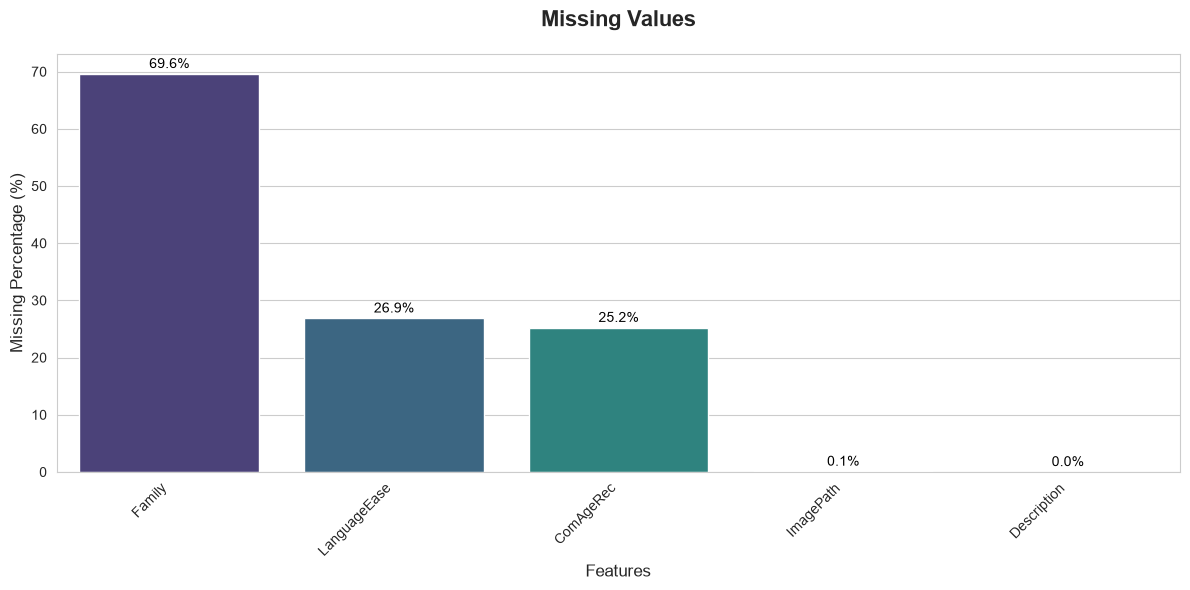

In [10]:
missing_data = df.isnull().mean() * 100

missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")  # Set a clean background with grid

# Create the barplot
# palette="viridis" creates a color gradient from yellow to purple based on the order
barplot = sns.barplot(
    x=missing_data.index, 
    y=missing_data.values, 
    palette="viridis", 
    hue=missing_data.index, 
    legend=False
)

# --- 3. Aesthetic customization ---
plt.title("Missing Values", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Missing Percentage (%)", fontsize=12)
plt.xlabel("Features", fontsize=12)

# Rotate X-axis labels to avoid overlapping
plt.xticks(rotation=45, ha='right')

# --- 4. Add labels above the bars ---
# This loop adds the exact percentage value above each bar
for p in barplot.patches:
    height = p.get_height()
    barplot.text(
        p.get_x() + p.get_width() / 2.,  # X position (center of the bar)
        height + 0.5,                    # Y position (above the bar)
        f'{height:.1f}%',                # Formatted text (e.g., 25.2%)
        ha="center", 
        va="bottom", 
        fontsize=10, 
        color="black"
    )

# Optimize spacing and display the plot
plt.tight_layout()
plt.show()

### Number of games that do not belong to any category

In [11]:
cat_features = [
    'Cat:Strategy', 'Cat:War', 'Cat:Family', 'Cat:CGS', 
    'Cat:Abstract', 'Cat:Party', 'Cat:Childrens'
]

df['Total_Categories'] = df[cat_features].sum(axis=1)

# if 'Total_Categories' == 0, the game does not belong to any of the listed categories
no_cat_games = df[df['Total_Categories'] == 0]

print(f"Total number of games: {len(df)}")
print(f"Number of games without any listed category: {len(no_cat_games)} ({(len(no_cat_games) / len(df)) * 100:.2f}%)")
print("-" * 35)

if not no_cat_games.empty:
    print("List of games without categories:")
    # Display only the game name and the control column
    print(no_cat_games[['Name', 'Total_Categories'] + cat_features])
else:
    print("All games in the dataset belong to at least one of the listed categories.")

Total number of games: 21925
Number of games without any listed category: 11852 (54.06%)
-----------------------------------
List of games without categories:
                          Name  Total_Categories  Cat:Strategy  Cat:War  \
0      Assassin's Creed: Arena                 0             0        0   
1                 Bag of Chips                 0             0        0   
2       Gùgōng: Deluxe Big Box                 0             0        0   
3                   LetterFlip                 0             0        0   
4          Treasures of Cibola                 0             0        0   
...                        ...               ...           ...      ...   
21918        Zoom in Barcelona                 0             0        0   
21919                   Diam's                 0             0        0   
21920                  Ballast                 0             0        0   
21921                 Leapfrog                 0             0        0   
21922           

### Number of games that belong to more than 1 category at the same time

In [12]:
multi_cat_games = df[df['Total_Categories'] > 1]
print(f"\nNumber of games that belong to more than 1 category at the same time: {len(multi_cat_games)} ({(len(multi_cat_games) / len(df)) * 100:.2f}%)")
print("-" * 35)
if not multi_cat_games.empty:
    print("List of games belonging to more than 1 category:")
    print(multi_cat_games[['Name', 'Total_Categories'] + cat_features])


Number of games that belong to more than 1 category at the same time: 1027 (4.68%)
-----------------------------------
List of games belonging to more than 1 category:
                                               Name  Total_Categories  \
30                                   Dinosaur Chess                 2   
69                                         De Stijl                 2   
91                                        Minuscule                 2   
140                                     Big Manitou                 2   
164                                  Cranium Zigity                 2   
...                                             ...               ...   
21839     San Juan Hill: The Santiago Campaign 1898                 2   
21869                        Yahtzee: Texas Hold'em                 2   
21875                                          Aton                 2   
21879                                     La Strada                 2   
21901  Summoner Wars: Guild 

### Logical inconsistencies

In [13]:
# A game cannot require more minimum players than the maximum allowed
df[df['MinPlayers'] > df['MaxPlayers']]

# The 132 cases occur because MaxPlayers = 0 (which is not a valid value).

,BGGId,Name,Description,YearPublished,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,...,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating,Total_Categories
206,39342,Bet Your Brain,trivium game question card question card q...,2008,2.3000,2.5258,2,0,9.000000,54.666667,...,0,0,0,0,0,0,0,0,Low,0
209,17568,Magic Robot Quiz Game,market board game magic robot quiz game probab...,1935,1.0000,1.2950,1,0,NaN,NaN,...,0,0,0,0,0,0,0,1,Low,1
604,66809,Flying Lead,fly lead play tabletop action wide range genre...,2010,2.6667,2.9662,2,0,NaN,NaN,...,0,0,1,0,0,0,0,0,High,1
640,38263,Sushi Bar,publisherquotsome chinese character fish shell...,2005,1.0000,1.1104,1,0,5.000000,47.000000,...,0,0,0,0,0,0,0,0,Medium,0
821,22289,Geni!,inside boxgeni question trivium game playersga...,0,1.8000,1.9822,1,0,10.000000,165.000000,...,0,0,0,0,0,0,0,0,Low,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20987,19796,Cranium: The Family Fun Game,manufacturer cranium family fun give family ...,2005,1.4444,1.6321,4,0,9.333333,5.000000,...,0,0,0,1,0,0,0,1,Low,2
21082,1540,BattleTech,battletech aka quotbtquot sciencefiction tacti...,1985,3.4178,3.7111,2,0,11.904762,22.866667,...,1,0,1,0,0,0,0,0,Medium,1
21201,131017,La Bérézina 1812,berezina focus batlle fight remnant napoleon...,2012,2.7500,2.9782,2,0,12.000000,22.500000,...,0,0,1,0,0,0,0,0,High,1
21246,131163,Ghost Hunt,turn light ready big thrillswith magical eye p...,2011,1.5000,1.7810,1,0,NaN,NaN,...,0,0,0,0,0,0,0,0,Low,0


In [14]:
# A game cannot have a minimum playtime greater than the maximum playtime
df[df['ComMinPlaytime'] > df['ComMaxPlaytime']]

# Some inconsistencies occur not only because ComMaxPlaytime = 0,
# but also because unrealistic values (e.g., 1 or 30 minutes) were recorded as maximum playtime.

,BGGId,Name,Description,YearPublished,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,...,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating,Total_Categories
100,197433,Miskatonic School for Boys,description publishermiskatonic school boy new...,2016,1.50,1.7245,3,6,NaN,NaN,...,0,0,0,0,0,0,0,0,Low,0
168,285789,Polyhedral Park Planner,big board gaming convention world come city lo...,2019,2.20,2.3922,1,100,10.000000,NaN,...,0,0,0,0,0,0,0,0,Medium,0
176,236556,Artifact Stack,discover old manuscript statue treasure excava...,2017,1.50,1.6919,2,4,NaN,NaN,...,0,0,0,0,0,0,0,0,Low,0
793,283795,Würfel-WG,roll dice new flatmember bring dice help launc...,2019,1.50,1.6079,2,4,10.000000,391.666667,...,0,0,0,0,0,0,0,0,Medium,0
1068,213421,Monster Kit,monster kit card match form monsterthere dif...,2016,1.20,1.3083,1,10,3.000000,66.000000,...,0,0,0,0,0,0,0,0,Medium,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21315,188930,Tue Fourre Marie... et pire encore!,here game adult want big fun eveninga super si...,2015,1.00,1.1634,3,10,17.600000,435.000000,...,0,0,0,0,0,0,0,0,Low,0
21400,188952,Maigo-Neko,preorderjapon brand httpjaponbrandmyshopifycom...,2015,1.50,1.6063,3,4,NaN,448.000000,...,0,0,0,0,0,0,0,0,Low,0
21508,257960,Götterdämmerung,goumltterdaumlmmerung player role norse god be...,2018,2.00,2.1062,7,15,NaN,631.000000,...,0,0,0,0,0,0,0,0,Medium,0
21561,183340,Der Schatz der 13 Inseln,description publisherwhos feel brave want exci...,2015,1.75,1.9551,2,4,5.000000,156.000000,...,0,0,0,0,0,0,0,0,Medium,0


--- ORIGINAL SKEWNESS ANALYSIS ---
ComMinPlaytime: 116.2071
ComMaxPlaytime: 74.7392


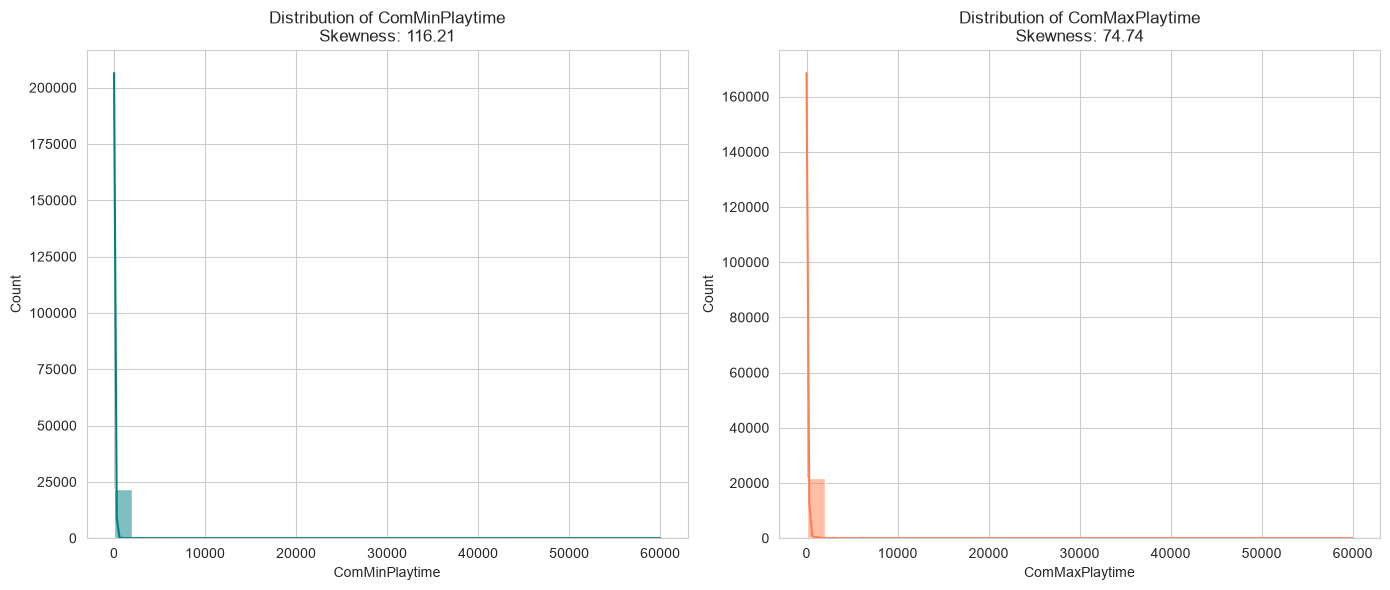


--- LOGARITHMIC TRANSFORMATION TEST (log1p) ---
Skewness of ComMinPlaytime (Log): -0.6780
Skewness of ComMaxPlaytime (Log): -0.7006


In [15]:
# 1. Compute the original skewness values
skew_com_min = df['ComMinPlaytime'].skew()
skew_com_max = df['ComMaxPlaytime'].skew()

print(f"--- ORIGINAL SKEWNESS ANALYSIS ---")
print(f"ComMinPlaytime: {skew_com_min:.4f}")
print(f"ComMaxPlaytime: {skew_com_max:.4f}")

# 2. Visualize the original distributions
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['ComMinPlaytime'], kde=True, color='teal', bins=30)
plt.title(f'Distribution of ComMinPlaytime\nSkewness: {skew_com_min:.2f}')

plt.subplot(1, 2, 2)
sns.histplot(df['ComMaxPlaytime'], kde=True, color='coral', bins=30)
plt.title(f'Distribution of ComMaxPlaytime\nSkewness: {skew_com_max:.2f}')

plt.tight_layout()
plt.show()

# 3. Quick test: does the logarithmic transformation improve the distribution?
print(f"\n--- LOGARITHMIC TRANSFORMATION TEST (log1p) ---")
print(f"Skewness of ComMinPlaytime (Log): {np.log1p(df['ComMinPlaytime']).skew():.4f}")
print(f"Skewness of ComMaxPlaytime (Log): {np.log1p(df['ComMaxPlaytime']).skew():.4f}")

In [16]:
# print rows where ComMinPlaytime and ComMaxPlaytime are both 0
df[(df['ComMinPlaytime'] == 0) & (df['ComMaxPlaytime'] == 0)]


,BGGId,Name,Description,YearPublished,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,...,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating,Total_Categories
6,25841,Le Grand Empire,le grand empire simulate napoleonic war st...,2007,3.7000,3.8964,2,7,NaN,388.0,...,0,0,1,0,0,0,0,0,High,1
112,14705,Totally Gross,publisherwant help kid understand chemistry bi...,2002,1.4000,1.5393,2,4,8.0,5.0,...,0,0,0,0,0,0,0,1,Low,1
116,19378,Doctor Who: The Interactive Electronic Board Game,base seasonquotyou doctor travel space colle...,2005,1.4286,1.5444,2,6,NaN,NaN,...,0,0,0,0,0,0,0,0,Low,0
135,73536,The Chinese Civil War of 1930,china complete unity warlord grasp real poli...,2010,2.8333,2.9672,2,5,8.0,474.0,...,0,0,1,0,0,0,0,0,Medium,1
154,15542,Orangino,publisher websiteorangino parlor game social g...,2002,1.0000,1.2483,2,6,NaN,NaN,...,0,0,0,0,0,0,0,0,Low,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21790,22674,Mława 1939,battle mlawa battle occur northern mazowsze ...,1999,3.0000,3.1347,2,2,16.0,8.0,...,0,0,1,0,0,0,0,0,Low,1
21812,167505,Star Wars Force Grab,fastaction family game kid adult ldquouse forc...,2014,1.2000,1.3904,2,6,3.0,251.0,...,0,0,0,0,0,0,0,0,Low,0
21817,139390,Perplexus Twist,perplexus twist new d maze game player maneuve...,2013,2.0000,2.1270,1,1,NaN,NaN,...,0,0,0,0,0,0,0,0,Medium,0
21837,19272,Go Fish!,watch preschooler hook fishy card game color...,1997,1.0000,1.2513,2,4,NaN,NaN,...,0,0,0,0,0,0,0,1,Low,1


In [17]:
df[['MfgAgeRec','ComAgeRec']].describe()

# no negative numbers
# 0 might be invalid or represent missing data

,MfgAgeRec,ComAgeRec
count,21925.000000,16395.000000
mean,9.613409,10.004391
std,3.641560,3.269157
min,0.000000,2.000000
25%,8.000000,8.000000
50%,10.000000,10.000000
75%,12.000000,12.000000
max,25.000000,21.000000


In [18]:
# 1. GameWeight < 1
count_gameweight_lt1 = len(df[df['GameWeight'] < 1])
print(f"Number of records with GameWeight < 1: {count_gameweight_lt1}")

# 2. GameWeight > 5
count_gameweight_gt5 = len(df[df['GameWeight'] > 5])
print(f"Number of records with GameWeight > 5: {count_gameweight_gt5}")

# 3. ComWeight < 1
count_comweight_lt1 = len(df[df['ComWeight'] < 1])
print(f"Number of records with ComWeight < 1: {count_comweight_lt1}")

# 4. ComWeight > 5
count_comweight_gt5 = len(df[df['ComWeight'] > 5])
print(f"Number of records with ComWeight > 5: {count_comweight_gt5}")

Number of records with GameWeight < 1: 506
Number of records with GameWeight > 5: 0
Number of records with ComWeight < 1: 506
Number of records with ComWeight > 5: 13


In [19]:
# Ranks should be positive numbers. Negative or zero ranks could indicate errors.
rank_cols = [c for c in df.columns if c.startswith('Rank:')]
df[(df[rank_cols] <= 0).any(axis=1)]

,BGGId,Name,Description,YearPublished,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,...,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating,Total_Categories


#### These rank anomalies are not necessarily data errors: a rank of 0 typically means the game is not ranked in that category (too few ratings), not an invalid value.


In [20]:
# Kickstarter started in 2009 — games marked as kickstarted before that are inconsistent.
# Kickstarter was founded in 2009

anomalous_kickstarted_games = df[(df['Kickstarted'] == 1) & (df['YearPublished'] < 2009)]
num_anomalies = len(anomalous_kickstarted_games)

print(f"Number of 'Kickstarted' anomalies (published before 2009): {num_anomalies}")

# Display the resulting DataFrame containing the anomalies (optional, but helpful for inspection)
# anomalous_kickstarted_games
print("List of anomalous 'Kickstarted' games published before 2009:")
a = anomalous_kickstarted_games[['Name', 'YearPublished', 'Kickstarted']]
a

Number of 'Kickstarted' anomalies (published before 2009): 83
List of anomalous 'Kickstarted' games published before 2009:


,Name,YearPublished,Kickstarted
880,Alquerque,1000,1
1188,The Cones of Dunshire,0,1
1293,Barca,2007,1
1496,Evil Dead 2: The Official Board Game,0,1
1624,War Titans: Invaders Must Die!,0,1
...,...,...,...
21109,Corsair Leader,2005,1
21264,Hoyuk,2006,1
21495,Metro,1997,1
21555,Moonstone,0,1


#### This inconsistency is not meaningful because the games were likely funded after their publication date.

### Outliers

#### YearPublished

In [21]:
df["YearPublished"].describe()

count    21925.000000
mean      1985.494914
std        212.486214
min      -3500.000000
25%       2001.000000
50%       2011.000000
75%       2017.000000
max       2021.000000
Name: YearPublished, dtype: float64

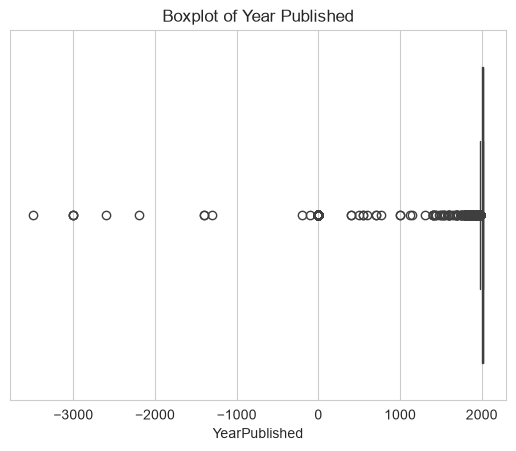

In [22]:
sns.boxplot(x=df['YearPublished'])
plt.title("Boxplot of Year Published")
plt.show()

In [23]:
df_ancient = df[df['YearPublished'] < 1900]
print("Games published before 1900:", df_ancient.shape[0])

df_modern = df[df['YearPublished'] >= 1900]
print("Games published after 1900:", df_modern.shape[0])


Games published before 1900: 309
Games published after 1900: 21616


In [24]:
df_ancient['YearPublished'].describe()

count     309.000000
mean      480.213592
std       946.057290
min     -3500.000000
25%         0.000000
50%         0.000000
75%      1550.000000
max      1899.000000
Name: YearPublished, dtype: float64

In [25]:
df_modern['YearPublished'].describe()

count    21616.000000
mean      2007.012861
std         13.682522
min       1900.000000
25%       2002.000000
50%       2012.000000
75%       2017.000000
max       2021.000000
Name: YearPublished, dtype: float64

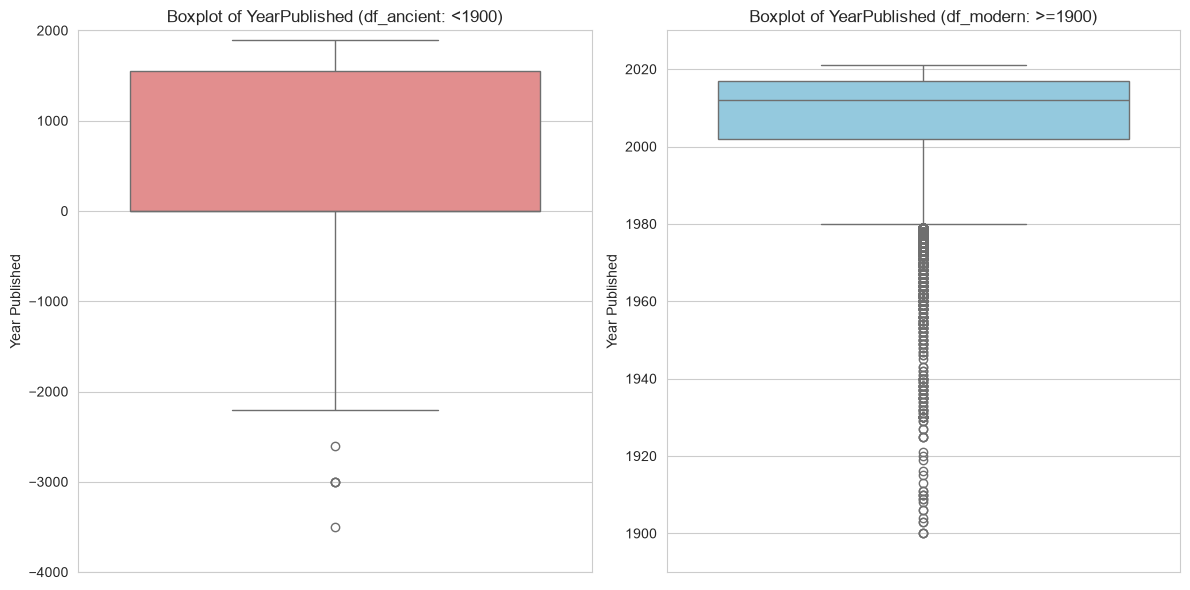

In [26]:
# Create the figure and axes for the side-by-side boxplots
plt.figure(figsize=(12, 6))

# --- Boxplot for df_ancient (Pre-1900 games) ---
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.boxplot(y=df_ancient['YearPublished'], color='lightcoral')
plt.title('Boxplot of YearPublished (df_ancient: <1900)')
plt.ylabel('Year Published')
# Set wide limits to capture extreme outliers like -3500 and 0
plt.ylim(ymin=-4000, ymax=2000) 

# --- Boxplot for df_modern (1900 and later games) ---
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.boxplot(y=df_modern['YearPublished'], color='skyblue')
plt.title('Boxplot of YearPublished (df_modern: >=1900)')
plt.ylabel('Year Published')
# Set tighter limits for clear visualization of the modern distribution
plt.ylim(ymin=1890, ymax=2030) 

plt.tight_layout() # Optimize subplot spacing
plt.show()

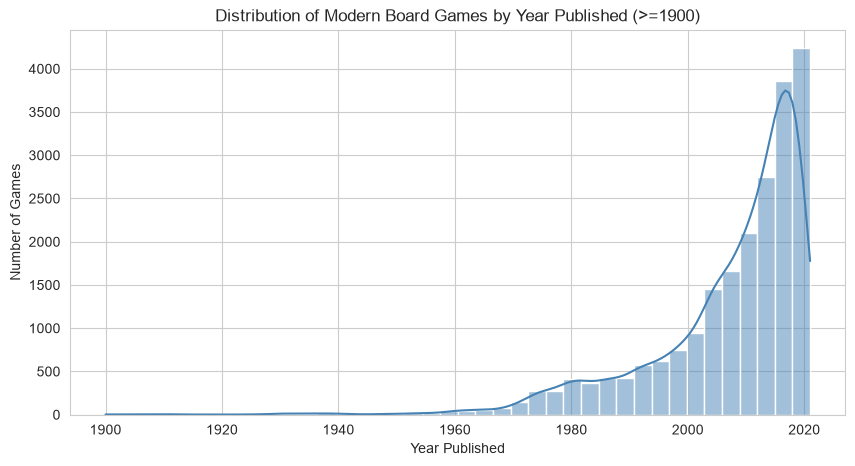

In [27]:
plt.figure(figsize=(10, 5))
sns.histplot(df_modern['YearPublished'], bins=40, kde=True, color='steelblue')
plt.title("Distribution of Modern Board Games by Year Published (>=1900)")
plt.xlabel("Year Published")
plt.ylabel("Number of Games")
plt.show()

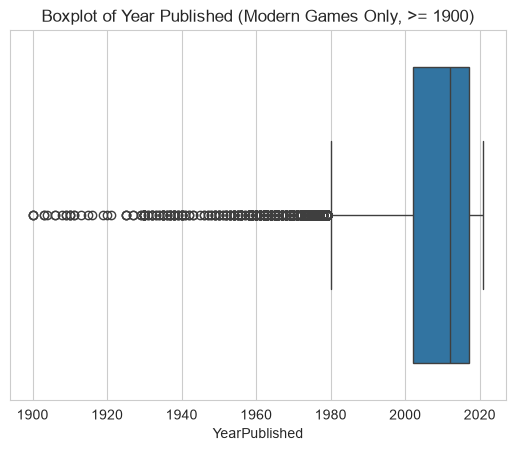

In [28]:
sns.boxplot(x=df_modern['YearPublished'])
plt.title("Boxplot of Year Published (Modern Games Only, >= 1900)")
plt.show()

# games published between 1900 and 1980 are identified as outliers.
# This is due to the majority of modern games being released after 1980, particularly in the 2000s.

In [29]:
# Count the number of games for each year in the modern subset (df_modern)
yearly_counts = df_modern['YearPublished'].value_counts().sort_index()

print("--- Number of Games Published Per Year (Since 1900) ---")
print(yearly_counts)

--- Number of Games Published Per Year (Since 1900) ---
YearPublished
1900       3
1903       2
1904       1
1906       2
1908       1
        ... 
2017    1356
2018    1351
2019    1302
2020     927
2021     660
Name: count, Length: 108, dtype: int64


#### MfgPlaytime, ComMinPlaytime, ComMaxPlaytime

In [30]:
# Display descriptive statistics for playtime-related features
# This helps identify potential anomalies such as unusually large or zero values
df[['MfgPlaytime', 'ComMinPlaytime', 'ComMaxPlaytime']].describe()

,MfgPlaytime,ComMinPlaytime,ComMaxPlaytime
count,21925.000000,21925.000000,21925.000000
mean,90.513523,63.678586,90.513523
std,529.657389,443.916212,529.657389
min,0.000000,0.000000,0.000000
25%,25.000000,20.000000,25.000000
50%,45.000000,30.000000,45.000000
75%,90.000000,60.000000,90.000000
max,60000.000000,60000.000000,60000.000000


In [31]:
# Inspect the specific record at index 4349
# This game shows extreme playtime values (60,000 minutes), which correspond
# to a title with theoretically unlimited duration according to external sources (e.g., Wikipedia)
df.loc[4349, ['Name', 'MfgPlaytime', 'ComMinPlaytime', 'ComMaxPlaytime']]

Name              The Campaign for North Africa: The Desert War ...
MfgPlaytime                                                   60000
ComMinPlaytime                                                60000
ComMaxPlaytime                                                60000
Name: 4349, dtype: object

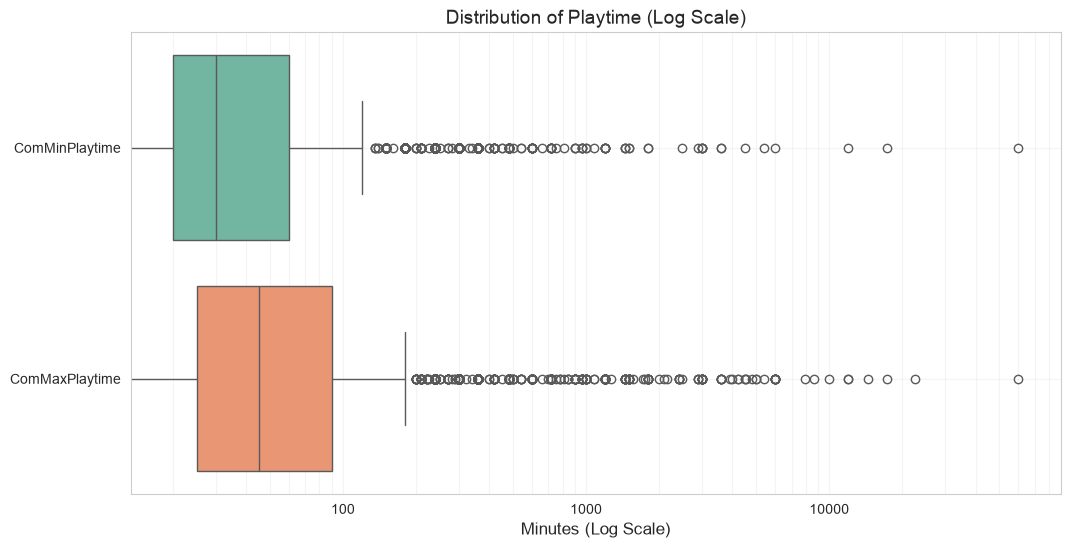

In [32]:
plt.figure(figsize=(12, 6))

# 1. Create the horizontal boxplot
sns.boxplot(data=df[['ComMinPlaytime', 'ComMaxPlaytime']], orient='h', palette='Set2')

# 2. APPLY LOGARITHMIC SCALE TO THE X-AXIS
plt.xscale('log')

# 3. Formatting to make numbers readable (e.g. 10, 100 instead of 10^1, 10^2)
plt.gca().xaxis.set_major_formatter(ScalarFormatter())

plt.title('Distribution of Playtime (Log Scale)', fontsize=14)
plt.xlabel('Minutes (Log Scale)', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.2)  # Add a light grid

plt.show()

### **3. Numerical features analysis**

#### GameWeight & ComWeight

In [33]:
print(df[['GameWeight', 'ComWeight']].describe())
print("\n")

         GameWeight     ComWeight
count  21925.000000  21925.000000
mean       1.982131      2.177479
std        0.848983      0.861781
min        0.000000      0.000000
25%        1.333300      1.513400
50%        1.968800      2.128000
75%        2.525200      2.737700
max        5.000000      5.213200




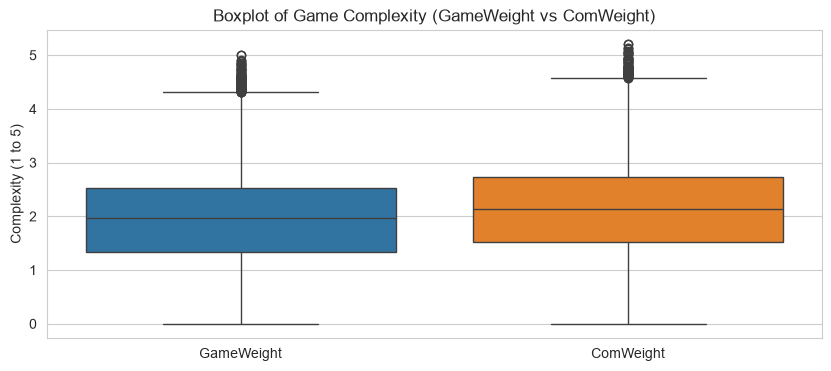

In [34]:
#Boxplot
plt.figure(figsize=(10, 4))
sns.boxplot(data=df[['GameWeight', 'ComWeight']])
plt.title("Boxplot of Game Complexity (GameWeight vs ComWeight)")
plt.ylabel("Complexity (1 to 5)")
plt.show()

In [35]:
corr = df[['GameWeight', 'ComWeight']].corr().iloc[0, 1]            #compute correlation
print(f"Correlation between GameWeight and ComWeight: {corr:.4f}")

Correlation between GameWeight and ComWeight: 0.9973


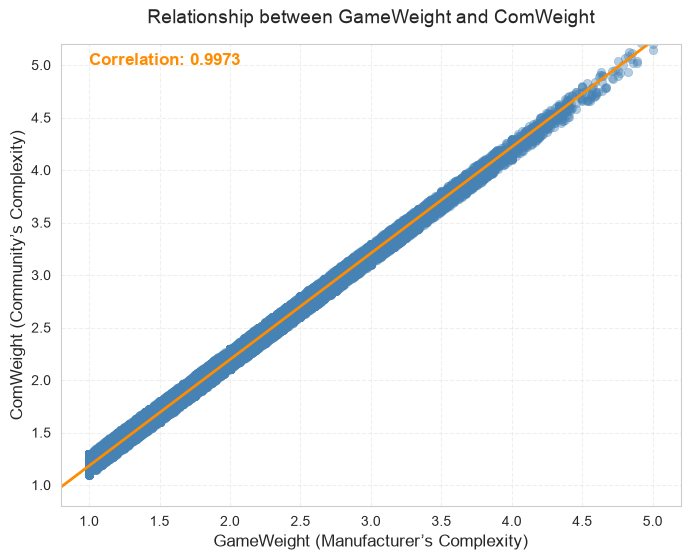

In [36]:
plt.figure(figsize=(8, 6))          #visualize correlation
sns.set_style("whitegrid")

sns.scatterplot(
    data=df,
    x='GameWeight',
    y='ComWeight',
    alpha=0.4,
    color='steelblue',
    edgecolor=None
)

# Regression line
sns.regplot(
    data=df,
    x='GameWeight',
    y='ComWeight',
    scatter=False,
    color='darkorange',
    line_kws={'linewidth': 2}
)

# Add correlation text
plt.text(
    1.0, 5.0,
    f"Correlation: {corr:.4f}",
    fontsize=12,
    color='darkorange',
    fontweight='bold'
)

# Formatting
plt.title('Relationship between GameWeight and ComWeight', fontsize=14, pad=15)
plt.xlabel("GameWeight (Manufacturer’s Complexity)", fontsize=12)
plt.ylabel("ComWeight (Community’s Complexity)", fontsize=12)
plt.xlim(0.8, 5.2)
plt.ylim(0.8, 5.2)
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

#### GameWeight & NumWeightVotes

In [37]:
# 1. Create Mask A: Rows where GameWeight is 0
mask_A = (df['GameWeight'] == 0.0)
num_zero_weight = mask_A.sum()

# 2. Create Mask B: Rows where NumWeightVotes is zero
mask_B = (df['NumWeightVotes'] == 0)
num_zero_votes = mask_B.sum()

# 3. Check 1: Are the zero values in GameWeight an exact subset of zero votes?
are_they_identical = (mask_A == mask_B).all()

# 4. Check 2: Find rows violating the condition (XOR operation)
violations = df[mask_A ^ mask_B]

print(f"Rows where GameWeight = 0: {num_zero_weight}")
print(f"Rows with NumWeightVotes = 0: {num_zero_votes}")
print("-" * 50)

if are_they_identical:
    print("Result: The two conditions are IDENTICAL for ALL rows.")
    print("The hypothesis is confirmed: Zero GameWeight values are solely caused by the absence of votes.")
else:
    print("Result: The two conditions are NOT identical (violations found).")
    print(f"Number of rows where A and B differ: {len(violations)}")
    
    # Print the first 5 anomalous cases for inspection
    if not violations.empty:
        print("\nFirst 5 violation cases:")
        print(violations[['Name', 'GameWeight', 'NumWeightVotes']].head())

Rows where GameWeight = 0: 506
Rows with NumWeightVotes = 0: 506
--------------------------------------------------
Result: The two conditions are IDENTICAL for ALL rows.
The hypothesis is confirmed: Zero GameWeight values are solely caused by the absence of votes.


#### LanguageEase

In [38]:
df["LanguageEase"].describe()

count    16034.000000
mean       216.461819
std        236.595136
min          1.000000
25%         24.027778
50%        138.000000
75%        351.000000
max       1757.000000
Name: LanguageEase, dtype: float64

In [39]:
# Correlation between LanguageEase and GameWeight
corr = df[['LanguageEase', 'GameWeight']].corr().iloc[0,1]
print(f"Correlation between LanguageEase and GameWeight: {corr:.4f}")

corr = df[['LanguageEase', 'GameWeight']].corr(method="spearman").iloc[0,1]
print(f"Spearman correlation between LanguageEase and GameWeight: {corr:.4f}")

corr = df[['LanguageEase', 'GameWeight']].corr(method="kendall").iloc[0,1]
print(f"Kendall correlation between LanguageEase and GameWeight: {corr:.4f}")

# There is no significant correlation (neither linear nor monotonic) between LanguageEase and GameWeight.
# In other words, language complexity does not appear to have any relationship with the game's weight in this dataset.

Correlation between LanguageEase and GameWeight: -0.0081
Spearman correlation between LanguageEase and GameWeight: -0.0348
Kendall correlation between LanguageEase and GameWeight: -0.0233


#### YearPublished

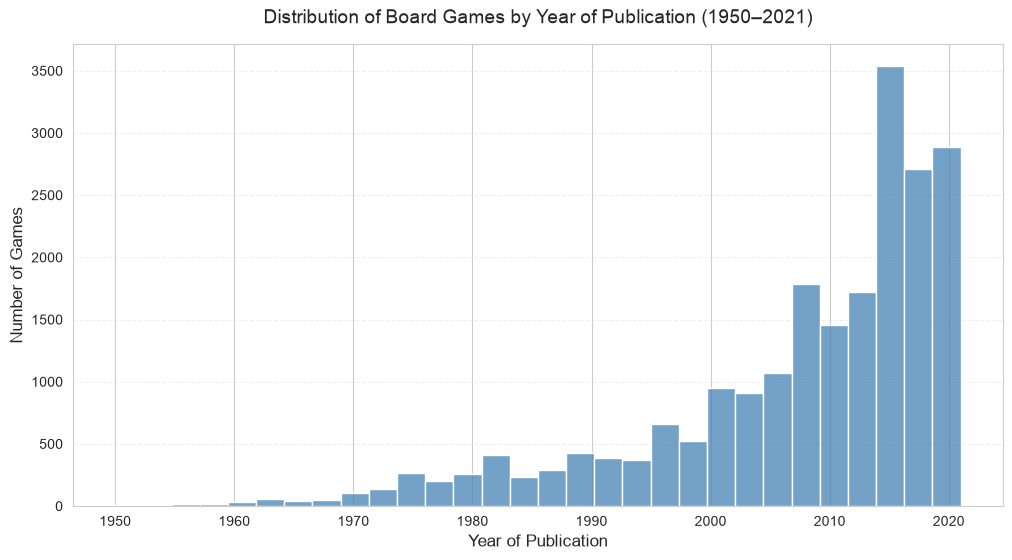

In [40]:
# --- Filter dataset for modern board games ---
df_modern = df[(df['YearPublished'] >= 1950) & (df['YearPublished'] <= 2021)]

# --- Plot histogram ---
plt.figure(figsize=(12, 6))
sns.histplot(
    data=df_modern,
    x='YearPublished',
    bins=30,          # number of bins for decade-level granularity
    color='steelblue',
    kde=False
)

# --- Add titles and labels ---
plt.title('Distribution of Board Games by Year of Publication (1950–2021)', fontsize=14, pad=15)
plt.xlabel('Year of Publication', fontsize=12)
plt.ylabel('Number of Games', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

### YearPublished & Kickstarter

In [41]:
# Filter the DataFrame to include only years from 2009 onwards (Kickstarter foundation year)
df_post_2009 = df[df['YearPublished'] >= 2009].copy()

# Group and calculate annual statistics
yearly_stats = df_post_2009.groupby('YearPublished').agg(
    TotalGames=('Name', 'count'),
    KickstartedGames=('Kickstarted', 'sum') # The sum of the binary variables gives the count
).reset_index()

# Calculate the percentage of crowdfunded games out of the annual total
yearly_stats['Crowdfunding_Share'] = (yearly_stats['KickstartedGames'] / yearly_stats['TotalGames']) * 100

print("Annual Crowdfunding Data (since 2009):")
print(yearly_stats)

Annual Crowdfunding Data (since 2009):
    YearPublished  TotalGames  KickstartedGames  Crowdfunding_Share
0            2009         647                12            1.854714
1            2010         710                21            2.957746
2            2011         746                47            6.300268
3            2012         843               117           13.879004
4            2013         875               221           25.257143
5            2014        1032               327           31.686047
6            2015        1185               385           32.489451
7            2016        1321               399           30.204391
8            2017        1356               364           26.843658
9            2018        1351               412           30.495929
10           2019        1302               391           30.030722
11           2020         927               294           31.715210
12           2021         660               289           43.787879


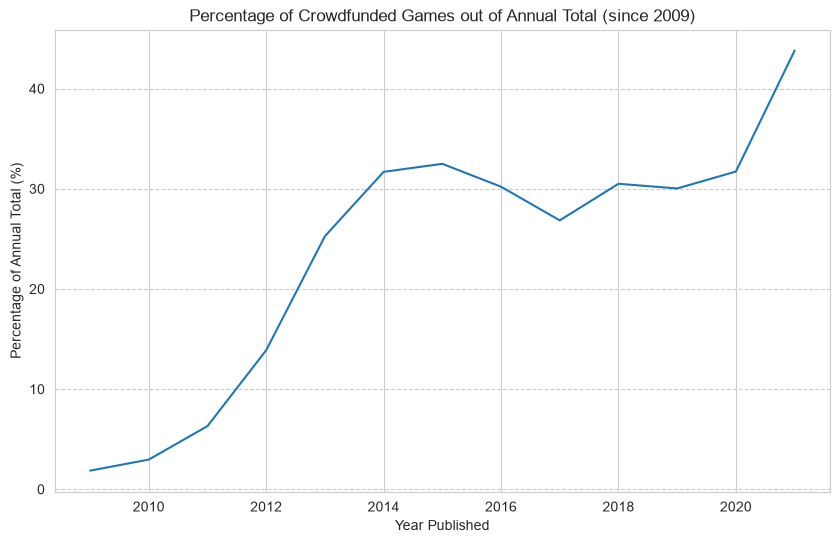

In [42]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    x='YearPublished', 
    y='Crowdfunding_Share', 
    data=yearly_stats
)
plt.title('Percentage of Crowdfunded Games out of Annual Total (since 2009)')
plt.ylabel('Percentage of Annual Total (%)')
plt.xlabel('Year Published')
plt.grid(axis='y', linestyle='--')
plt.show()

In [43]:
# correlation between 'Kickstarted' and 'YearPublished' for games published from 2009 onwards
correlation_results = df_post_2009[['Kickstarted', 'YearPublished']].corr()
    
print(correlation_results.loc['Kickstarted', ['YearPublished']])

YearPublished    0.214033
Name: Kickstarted, dtype: float64


#### MfgAgeRec & ComAgeRec

In [44]:
df[['MfgAgeRec', 'ComAgeRec']].describe()

,MfgAgeRec,ComAgeRec
count,21925.000000,16395.000000
mean,9.613409,10.004391
std,3.641560,3.269157
min,0.000000,2.000000
25%,8.000000,8.000000
50%,10.000000,10.000000
75%,12.000000,12.000000
max,25.000000,21.000000


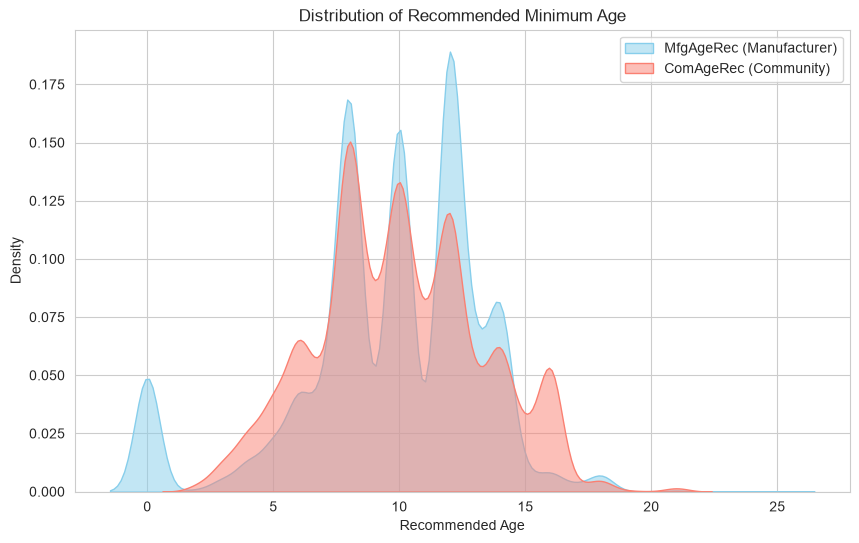

In [45]:
# KDE plot

plt.figure(figsize=(10, 6))
sns.kdeplot(df['MfgAgeRec'], fill=True, color='skyblue', alpha=0.5, label='MfgAgeRec (Manufacturer)')
sns.kdeplot(df['ComAgeRec'], fill=True, color='salmon', alpha=0.5, label='ComAgeRec (Community)')

plt.title('Distribution of Recommended Minimum Age')
plt.xlabel('Recommended Age')
plt.ylabel('Density')
plt.legend()
plt.show()

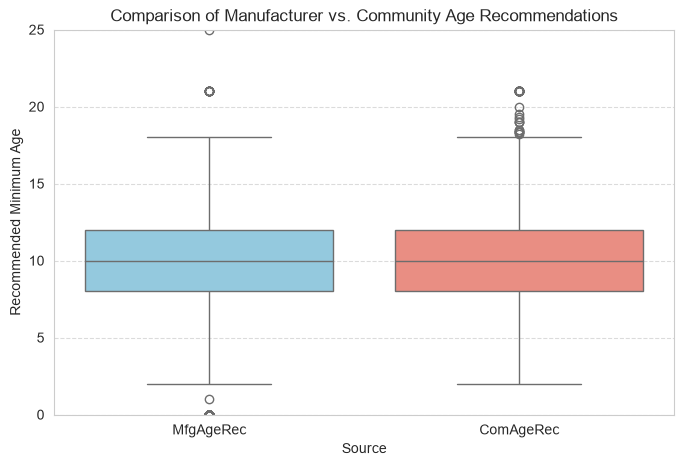

In [46]:
# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[['MfgAgeRec', 'ComAgeRec']], palette=['skyblue', 'salmon'])
plt.title('Comparison of Manufacturer vs. Community Age Recommendations')
plt.ylabel('Recommended Minimum Age')
plt.xlabel('Source')
plt.ylim(0, 25)  # focus on realistic values
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [47]:
corr = df[['MfgAgeRec', 'ComAgeRec']].corr().iloc[0,1]
print(f"Correlation between MfgAgeRec and ComAgeRec: {corr:.3f}")

# This correlation does not account for the fact that ComAgeRec contains a large number of zero values.

Correlation between MfgAgeRec and ComAgeRec: 0.433


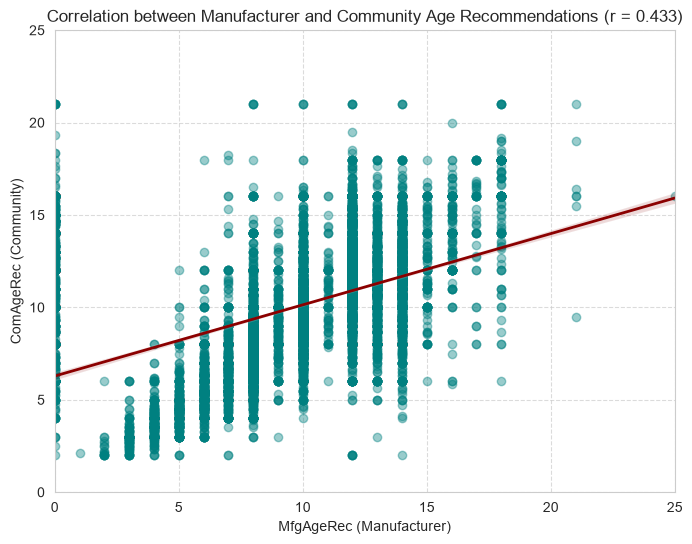

In [48]:
#visualize correlation
sns.set_style("whitegrid")

plt.figure(figsize=(8, 6))

# --- Scatterplot with regression line ---
sns.regplot(
    data=df,
    x='MfgAgeRec',
    y='ComAgeRec',
    scatter_kws={'alpha': 0.4, 'color': 'teal'},
    line_kws={'color': 'darkred', 'lw': 2},
)

# Add labels and title
plt.title(f'Correlation between Manufacturer and Community Age Recommendations (r = {corr:.3f})')
plt.xlabel('MfgAgeRec (Manufacturer)')
plt.ylabel('ComAgeRec (Community)')
plt.grid(True, linestyle='--', alpha=0.7)

# Optional: set reasonable axis limits
plt.xlim(0, 25)
plt.ylim(0, 25)

plt.show()

#### NumOwned, NumWant, NumWish, NumUserRatings, NumComments 

In [49]:
print(df[['NumOwned', 'NumWant','NumWish','NumUserRatings', 'NumComments']].describe())
print("\n")

            NumOwned       NumWant       NumWish  NumUserRatings  NumComments
count   21925.000000  21925.000000  21925.000000    21925.000000      21925.0
mean     1467.848164     41.690946    228.457013      861.668324          0.0
std      5294.120574    117.255229    788.477151     3638.680857          0.0
min         0.000000      0.000000      0.000000       30.000000          0.0
25%       150.000000      3.000000     14.000000       56.000000          0.0
50%       320.000000      9.000000     39.000000      123.000000          0.0
75%       899.000000     28.000000    127.000000      395.000000          0.0
max    166497.000000   2031.000000  19182.000000   108101.000000          0.0




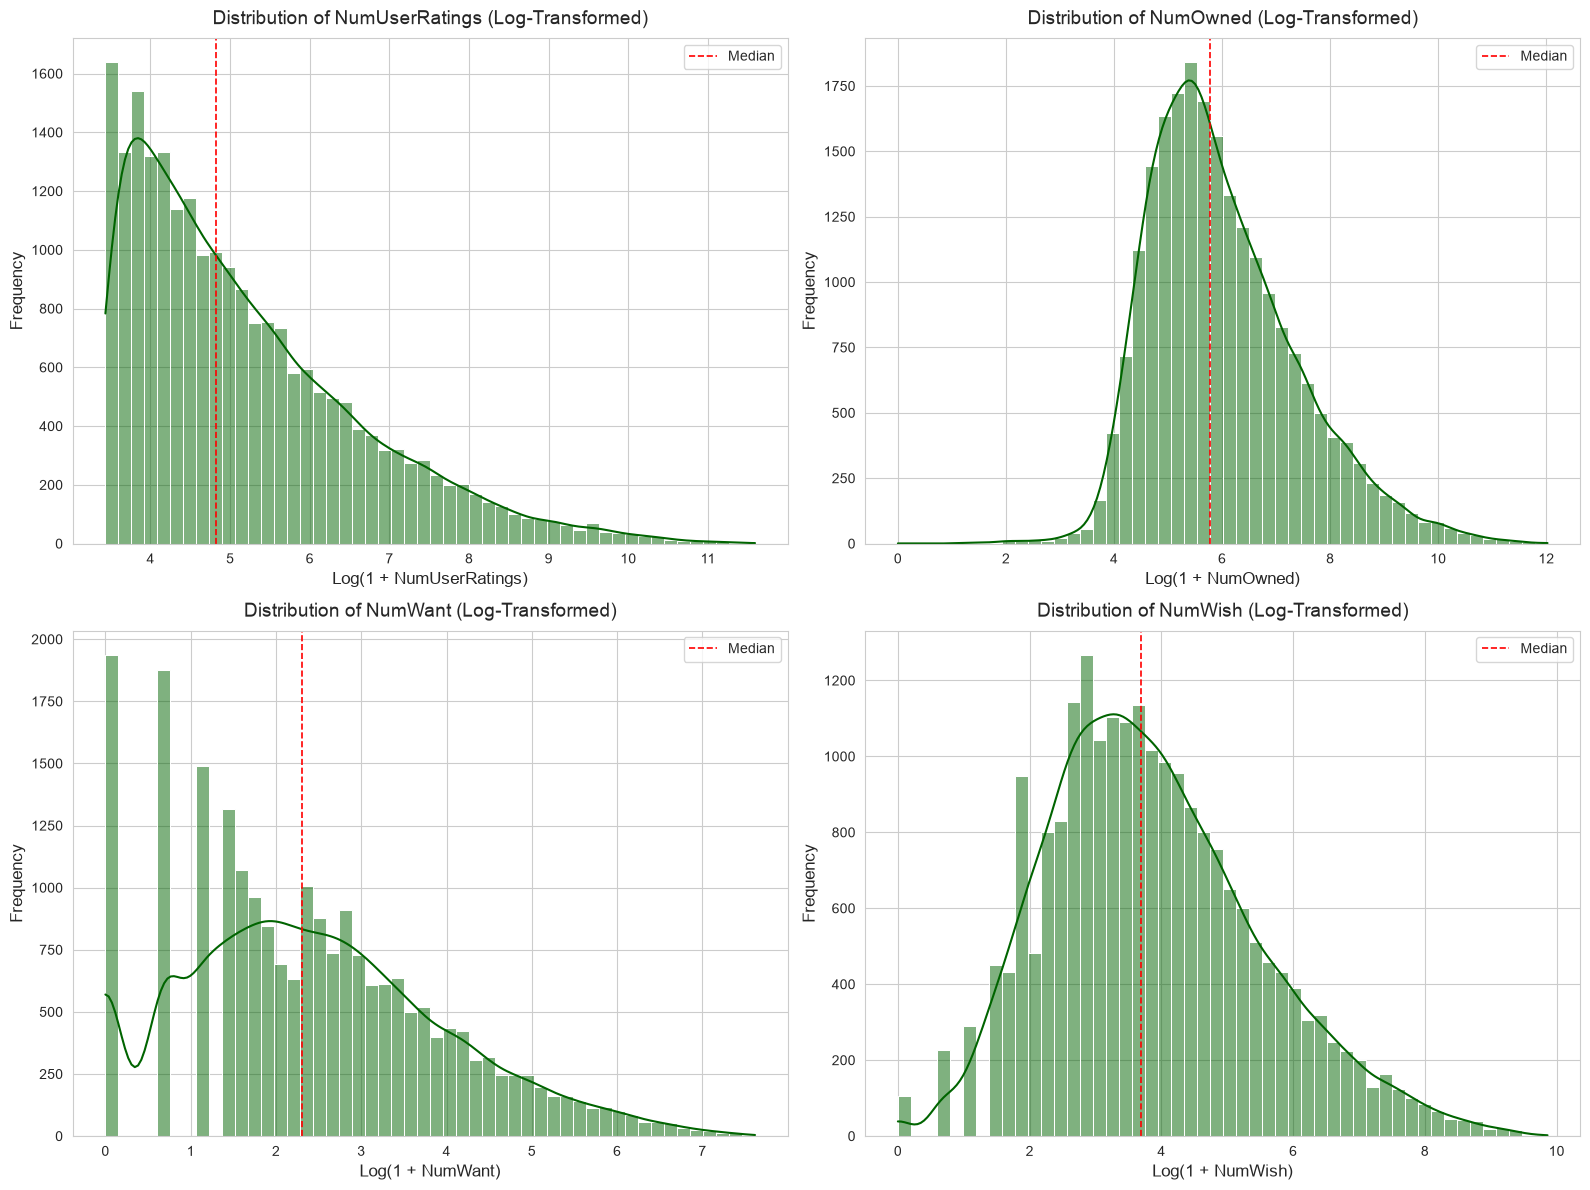

In [50]:
# Visualization

# Set a clean visual style
sns.set_style("whitegrid")

# Features representing game popularity and engagement
popularity_features = ['NumUserRatings', 'NumOwned', 'NumWant', 'NumWish']

# Create a figure with four subplots (2 rows × 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()  # Flatten the axes array for easy iteration

for i, feature in enumerate(popularity_features):
    # Apply log(1 + X) transformation to handle extreme skewness
    log_data = np.log1p(df[feature])
    
    # Plot histogram with KDE overlay
    sns.histplot(
        x=log_data,
        bins=50,
        color='darkgreen',
        ax=axes[i],
        kde=True
    )
    
    # Add median reference line
    axes[i].axvline(log_data.median(), color='red', linestyle='--', linewidth=1.2, label='Median')
    
    # Titles and labels
    axes[i].set_title(f'Distribution of {feature} (Log-Transformed)', fontsize=14, pad=10)
    axes[i].set_xlabel(f'Log(1 + {feature})', fontsize=12)
    axes[i].set_ylabel('Frequency', fontsize=12)
    axes[i].legend()

# Adjust layout for better readability
plt.tight_layout()
plt.show()


In [51]:
#correlazione tra NumWant e NumWish
corr = df[['NumWant', 'NumWish']].corr().iloc[0,1]
print(f"Correlation between NumWant and NumWish: {corr:.4f}")

Correlation between NumWant and NumWish: 0.9398


### **4. Categorical features analysis**

#### BestPlayers & GoodPlayers

- 'BestPlayers' represents the single best number of players for a game,
-  'GoodPlayers' is a list (array) of community-recommended player counts.

In [52]:
print(df['BestPlayers'].dtype)
print(type(df['GoodPlayers'].iloc[0]))

int64
<class 'str'>


In [53]:
# 1. Check how many entries in 'BestPlayers' are zero
best_players = df["BestPlayers"]
num_of_0 = (best_players == 0).sum()
perc_of_0 = (num_of_0 / len(best_players)) * 100
print(f"Percentage of 0 values in BestPlayers: {perc_of_0:.2f}%")

# 2. Check how many entries in 'GoodPlayers' are empty arrays
good_players = df["GoodPlayers"]
num_empty_arrays = (good_players == "[]").sum()
perc_empty_arrays = (num_empty_arrays / len(good_players)) * 100
print(f"Percentage of empty arrays in GoodPlayers: {perc_empty_arrays:.2f}%")

# 3. Display the two columns for a quick structural check
df[["BestPlayers", "GoodPlayers"]]

# Observation:
# More than 90% of 'BestPlayers' are zeros and 'GoodPlayers' contain empty arrays.
# This suggests that these features have limited informational value
# and may represent missing or incomplete data.

Percentage of 0 values in BestPlayers: 90.96%
Percentage of empty arrays in GoodPlayers: 90.97%


,BestPlayers,GoodPlayers
0,0,[]
1,0,[]
2,0,[]
3,0,[]
4,0,[]
...,...,...
21920,0,[]
21921,0,[]
21922,0,[]
21923,0,[]


#### Rating

In [54]:
df['Rating'].value_counts()

Rating
Medium    9644
Low       7245
High      5036
Name: count, dtype: int64

In [55]:
rating_counts=df['Rating'].value_counts(normalize=True) * 100  # Percentage
print(rating_counts)

Rating
Medium    43.986317
Low       33.044470
High      22.969213
Name: proportion, dtype: float64


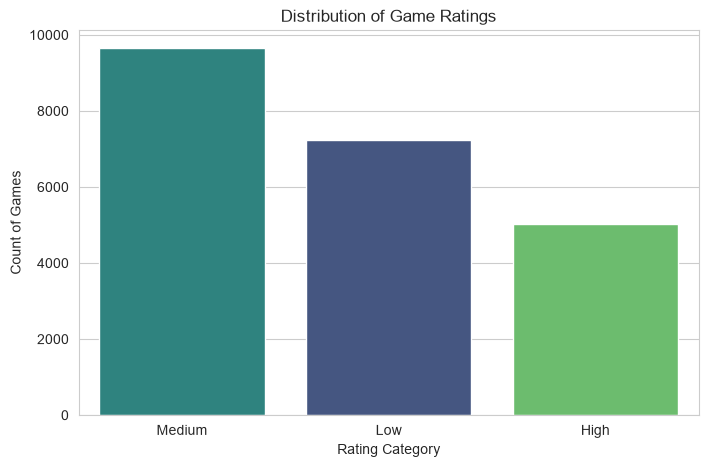

In [56]:
# Visualize distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Rating', order=rating_counts.index, hue='Rating', palette='viridis', legend=False)

plt.title('Distribution of Game Ratings')
plt.xlabel('Rating Category')
plt.ylabel('Count of Games')
plt.show()

#### Family

In [57]:
top20_families = df['Family'].value_counts().head(20)
print("\nTop 20 Game Families:\n", top20_families)


Top 20 Game Families:
 Family
18xx                                         103
Monopoly (Official)                           73
Trivial Pursuit                               67
Werewolf / Mafi                               58
Wallet Games (Button Shy)                     45
Two-player games (Kosmos)                     44
Cluedo / Clue (Parker Brothers, et al)        42
Munchkin                                      41
UNO                                           39
Monopoly-Lik                                  39
Fluxx                                         38
LEGO Gam                                      34
Catan                                         34
Risk (Official)                               32
Fantasy Flight Silver Lin                     32
Cube Rail                                     31
NSV Middys (Nürnberger Spielkartenverlag)     29
Unlock! (Space Cowboys)                       29
Anno Domini                                   29
Exit – The Gam                        

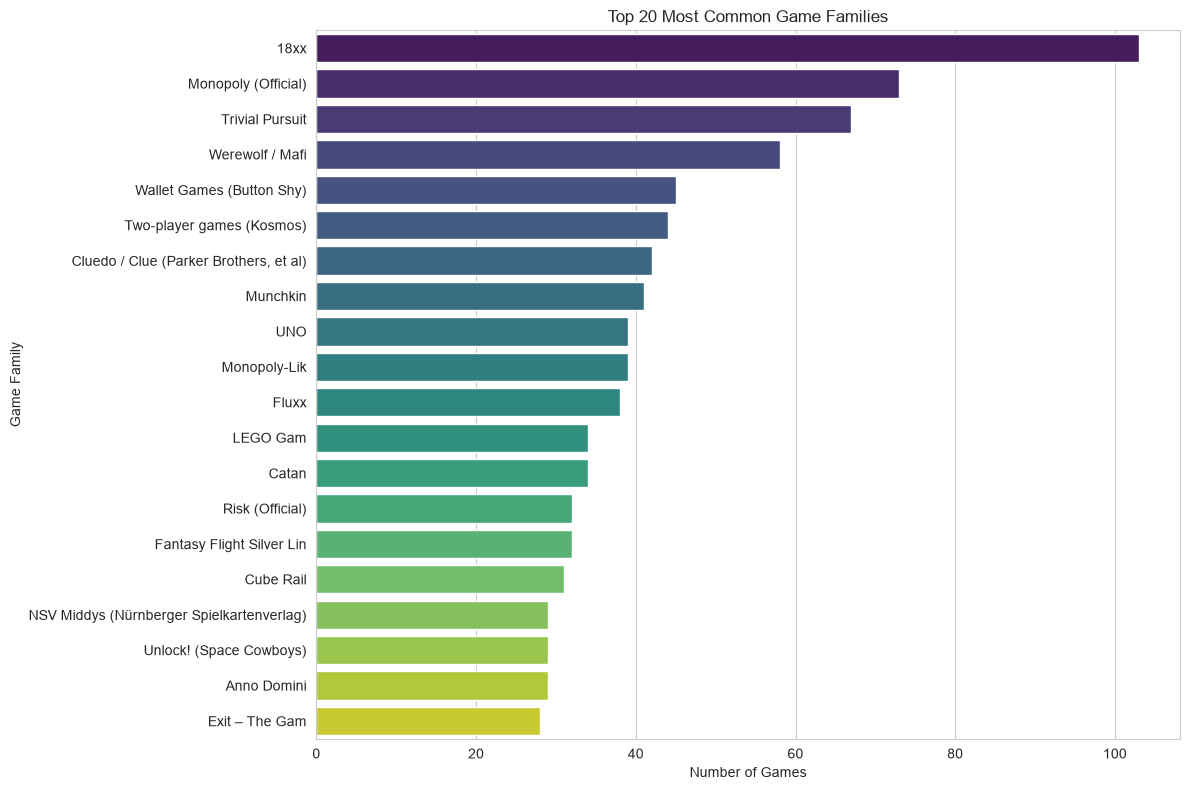


Percentage of missing values in Family: 69.61%


In [58]:
# Visualization of the distribution
plt.figure(figsize=(12, 8))
sns.barplot(
    x=top20_families.values,
    y=top20_families.index,
    hue=top20_families.index,
    palette='viridis',
    legend=False
)

plt.title('Top 20 Most Common Game Families')
plt.xlabel('Number of Games')
plt.ylabel('Game Family')
plt.tight_layout()
plt.show()

# Missing values analysis
total_rows = len(df)
missing_ratio = (df['Family'].isnull().sum() / total_rows) * 100
print(f"\nPercentage of missing values in Family: {missing_ratio:.2f}%")

# Most games do not have a recorded Family value (around 70% missing).
# The distribution is heavily right-skewed, with a few popular families dominating.
# This feature could be used for categorical analysis, but rare categories may need to be grouped as 'Other'.

#### Kickstarted

In [59]:
# Check how many 0s and 1s are in Kickstarted
number_of_ones = df['Kickstarted'].value_counts().get(1, 0)
print(f"The number of occurrences with value 1 in the Kickstarted column is: {number_of_ones}")
number_of_zeros = df['Kickstarted'].value_counts().get(0, 0)
print(f"The number of occurrences with value 0 in the Kickstarted column is: {number_of_zeros}")
number_of_ones + number_of_zeros

The number of occurrences with value 1 in the Kickstarted column is: 3362
The number of occurrences with value 0 in the Kickstarted column is: 18563


np.int64(21925)

#### Cat features

Nota: qui si usa un barplot invece di un grafico a torta. Le categorie (`Cat:*`) non sono mutuamente esclusive — il 4.68% dei giochi appartiene a più di una categoria (vedi sopra) — quindi una torta, che implica che le fette sommino al 100%, sarebbe fuorviante.


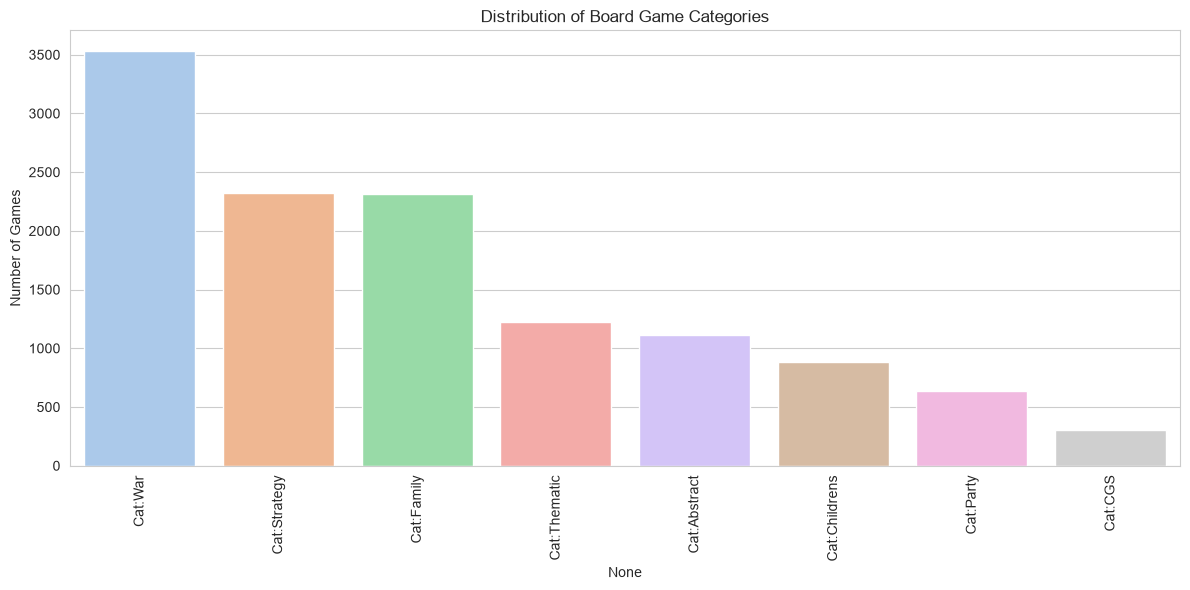

In [60]:
# Distribution of Category features (barplot; categories are not mutually exclusive, see note above)
category_features = [col for col in df.columns if col.startswith('Cat:')]
category_sums = df[category_features].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=category_sums.index, y=category_sums.values, hue=category_sums.index, palette='pastel', legend=False)
plt.xticks(rotation=90)
plt.title('Distribution of Board Game Categories')
plt.ylabel('Number of Games')
plt.tight_layout()
plt.show()

#### Cat and Rank Features

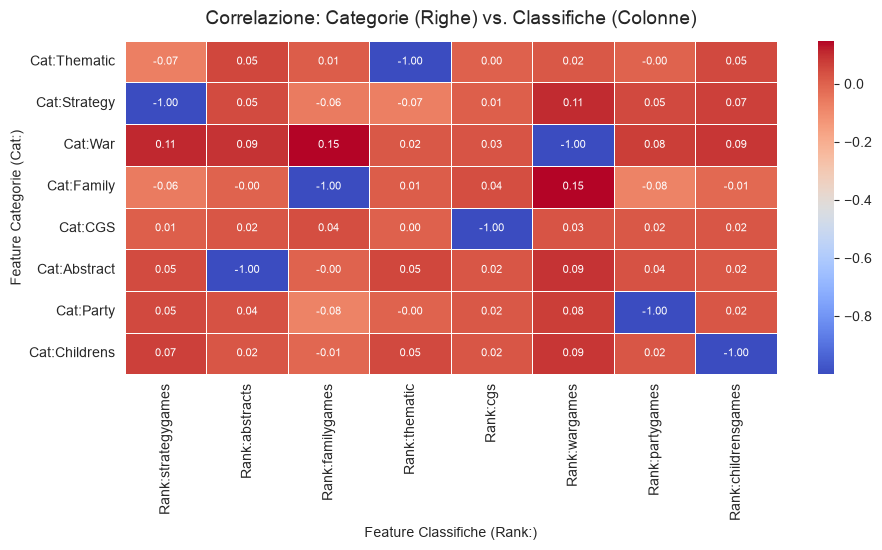

In [61]:
cat_features = [col for col in df.columns if col.startswith('Cat:')]
rank_features = [col for col in df.columns if col.startswith('Rank:')]

cat_df = df[cat_features]
rank_df = df[rank_features]

combined_df = pd.concat([cat_df, rank_df], axis=1)

full_corr_matrix = combined_df.corr()

corr_matrix_cat_vs_rank = full_corr_matrix.loc[cat_features, rank_features]

plt.figure(figsize=(len(rank_features) * 1.2, len(cat_features) * 0.7))
sns.set_style("whitegrid")
sns.heatmap(
    corr_matrix_cat_vs_rank,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=True,
    square=False,
    linewidths=0.5,
    annot_kws={"size": 8}
)
plt.title("Correlazione: Categorie (Righe) vs. Classifiche (Colonne)", fontsize=14, pad=12)
plt.ylabel('Feature Categorie (Cat:)', fontsize=10)
plt.xlabel('Feature Classifiche (Rank:)', fontsize=10)
plt.tight_layout()
plt.show()

Checking whether GameWeight, MinPlayers, MaxPlayers, ComAgeRec, LanguageEase, ComMinPlaytime, and ComMaxPlaytime vary substantially by category. If so, mode/median imputation can be done using the category's mean/median. Otherwise, the global mean/median is used.

In [62]:
# List of numerical variables to test (your dependent variables)
NUMERIC_VARIABLES = [
    'GameWeight', 'MinPlayers', 'MaxPlayers', 'ComAgeRec', 
    'LanguageEase', 'ComMinPlaytime', 'ComMaxPlaytime'
]

# List of categorical variables (your binary independent variables)
# Use the column names exactly as they appear in your DataFrame
CATEGORIES = [
    'Cat:Thematic', 'Cat:Strategy', 'Cat:War', 'Cat:Family', 
    'Cat:CGS', 'Cat:Abstract', 'Cat:Party', 'Cat:Childrens'
]

In [63]:
# Significance level (alpha): if p-value < 0.05, there is a significant difference
ALPHA = 0.05

# --- ANALYSIS FUNCTION ---

def verify_category_variation(df, numeric_variables, categories, alpha=0.05):
    """
    Performs the Wilcoxon-Mann-Whitney test (non-parametric)
    to compare a numerical variable between the YES/NO groups of a category.
    """
    results = {}
    
    for cat in categories:
        results[cat] = {}
        print(f"--- Analysis for Category: {cat} ---")
        
        # Filter groups:
        # Category-YES: Records belonging to this category (e.g., Cat:Strategy == 1)
        # Category-NO: Records not belonging to this category (e.g., Cat:Strategy == 0)
        group_yes = df[df[cat] == 1].copy()
        group_no = df[df[cat] == 0].copy()
        
        # Check that both groups are not empty
        if group_yes.empty or group_no.empty:
            print(f"Warning: one of the groups for {cat} is empty. Skipping.")
            continue
            
        for var in numeric_variables:
            # Remove NaN values, as statistical tests require complete data
            data_yes = group_yes[var].dropna()
            data_no = group_no[var].dropna()
            
            # Check that enough data is available after cleaning
            if len(data_yes) < 2 or len(data_no) < 2:
                results[cat][var] = {
                    'p_value': None,
                    'significant': False,
                    'comment': 'Insufficient data for the test.'
                }
                continue

            # Perform the Wilcoxon-Mann-Whitney test (non-parametric statistical test)
            # This test evaluates whether the distributions of the two populations differ.
            stat, p_value = stats.mannwhitneyu(data_yes, data_no, alternative='two-sided')
            
            # Determine statistical significance
            significant = p_value < alpha
            
            # Calculate descriptive statistics for interpretation
            median_yes = data_yes.median()
            median_no = data_no.median()
            
            results[cat][var] = {
                'p_value': p_value,
                'significant': significant,
                'median_yes': median_yes,
                'median_no': median_no,
                'comment': f"Median {cat} YES: {median_yes:.2f}, Median {cat} NO: {median_no:.2f}"
            }
            
            print(f"  {var}: p-value = {p_value:.4f}", end="")
            if significant:
                print(f" -> **SIGNIFICANT** ({results[cat][var]['comment']})")
            else:
                print(f" -> Not significant ({results[cat][var]['comment']})")

    return pd.DataFrame.from_dict({(i, j): results[i][j] 
                                    for i in results.keys() 
                                    for j in results[i].keys()}, 
                                   orient='index')

In [64]:
# --- EXECUTION ---
df_test = df.copy()

# Update the CATEGORIES and NUMERIC_VARIABLES lists for the test example
CATEGORIES_TEST = CATEGORIES.copy()
TEST_VARIABLES = ['GameWeight', 'ComAgeRec', 'LanguageEase', 'ComMinPlaytime', 'ComMaxPlaytime']

print("\n\n--- STARTING STATISTICAL ANALYSIS ---")
results_df = verify_category_variation(df_test, TEST_VARIABLES, CATEGORIES_TEST, ALPHA)

# --- MULTIPLE TESTING CORRECTION ---
# We are running len(CATEGORIES_TEST) * len(TEST_VARIABLES) independent tests with a fixed
# alpha = 0.05. Without correcting for that, the expected number of false positives grows with
# the number of tests. We apply the Benjamini-Hochberg (FDR) correction, which is less
# conservative than Bonferroni and more appropriate for exploratory analysis like this one.
valid_mask = results_df['p_value'].notna()
p_values = results_df.loc[valid_mask, 'p_value'].values

reject, p_adjusted, _, _ = multipletests(p_values, alpha=ALPHA, method='fdr_bh')

results_df['p_value_adj'] = np.nan
results_df['significant_adj'] = False
results_df.loc[valid_mask, 'p_value_adj'] = p_adjusted
results_df.loc[valid_mask, 'significant_adj'] = reject

n_sig_raw = results_df['significant'].sum()
n_sig_adj = results_df['significant_adj'].sum()
print(f"\nSignificant results before FDR correction: {n_sig_raw} / {valid_mask.sum()}")
print(f"Significant results after FDR correction (Benjamini-Hochberg): {n_sig_adj} / {valid_mask.sum()}")

print("\n--- RESULTS SUMMARY (adjusted) ---")
print(results_df[['significant', 'p_value', 'p_value_adj', 'significant_adj', 'median_yes', 'median_no']])




--- STARTING STATISTICAL ANALYSIS ---
--- Analysis for Category: Cat:Thematic ---
  GameWeight: p-value = 0.0000 -> **SIGNIFICANT** (Median Cat:Thematic YES: 2.38, Median Cat:Thematic NO: 1.90)
  ComAgeRec: p-value = 0.0000 -> **SIGNIFICANT** (Median Cat:Thematic YES: 11.33, Median Cat:Thematic NO: 10.00)
  LanguageEase: p-value = 0.0000 -> **SIGNIFICANT** (Median Cat:Thematic YES: 73.08, Median Cat:Thematic NO: 143.80)
  ComMinPlaytime: p-value = 0.0000 -> **SIGNIFICANT** (Median Cat:Thematic YES: 60.00, Median Cat:Thematic NO: 30.00)
  ComMaxPlaytime: p-value = 0.0000 -> **SIGNIFICANT** (Median Cat:Thematic YES: 90.00, Median Cat:Thematic NO: 45.00)
--- Analysis for Category: Cat:Strategy ---
  GameWeight: p-value = 0.0000 -> **SIGNIFICANT** (Median Cat:Strategy YES: 2.62, Median Cat:Strategy NO: 1.80)
  ComAgeRec: p-value = 0.0000 -> **SIGNIFICANT** (Median Cat:Strategy YES: 11.20, Median Cat:Strategy NO: 9.67)
  LanguageEase: p-value = 0.0000 -> **SIGNIFICANT** (Median Cat:Strate

### Variables with Significant Test Results

- **GameWeight**: Significant differences were found for all categories (YES is higher for Thematic, Strategy, War, and CGS; NO is higher for Family, Party, and Childrens), except for Cat:Abstract.

- **ComAgeRec**: All categories show significant differences between the YES and NO groups.

- **ComMinPlaytime**: All categories show significant differences between the YES and NO groups, except for Cat:CGS.

- **ComMaxPlaytime**: All categories show significant differences between the YES and NO groups, except for Cat:CGS.

- **LanguageEase**: All categories show significant differences between the YES and NO groups, except for Cat:War.

> **Note:** this summary is based on unadjusted p-values. After the FDR correction (Benjamini-Hochberg, see cell above), some marginal results may no longer be significant — refer to the `significant_adj` column for the final conclusions to use in the data preparation phase.


In [65]:
# --- MODE ANALYSIS FUNCTION ---

def compare_mode_by_category(df, numeric_variables, categories):
    """
    Calculates and compares the mode of each numerical variable
    between the YES/NO groups of each category (descriptive analysis).
    """
    mode_results = []
    
    for cat in categories:
        print(f"--- Mode Analysis for Category: {cat} ---")
        
        # Filter groups:
        # Category-YES: Records belonging to this category (e.g., Cat:Strategy == 1)
        # Category-NO: Records not belonging to this category (e.g., Cat:Strategy == 0)
        group_yes = df[df[cat] == 1].copy()
        group_no = df[df[cat] == 0].copy()
        
        if group_yes.empty or group_no.empty:
            print(f"Warning: one of the groups for {cat} is empty. Skipping.")
            continue
            
        for var in numeric_variables:
            # Remove NaN values
            data_yes = group_yes[var].dropna()
            data_no = group_no[var].dropna()
            
            # Calculate the mode
            # .mode() returns a Series (it may contain multiple modes), so we take the first value
            mode_yes = data_yes.mode().iloc[0] if not data_yes.mode().empty else None
            mode_no = data_no.mode().iloc[0] if not data_no.mode().empty else None
            
            # Simple comparison between modes
            different_modes = (mode_yes != mode_no)
            
            mode_results.append({
                'Category': cat,
                'Variable': var,
                'Mode_YES': mode_yes,
                'Mode_NO': mode_no,
                'Different_Modes': different_modes
            })
            
            print(f"  {var}: Mode YES ({cat} = 1): {mode_yes}, Mode NO ({cat} = 0): {mode_no}", end="")
            if different_modes:
                print(f" -> **DIFFERENT**")
            else:
                print(f" -> Equal")


    return pd.DataFrame(mode_results)

# --- EXECUTION (with a dummy example) ---

df_test = df.copy()

# Update the CATEGORIES and NUMERIC_VARIABLES lists for the dummy example
CATEGORIES_TEST = NUMERIC_VARIABLES.copy()
TEST_VARIABLES = ['MinPlayers', 'MaxPlayers', 'ComAgeRec']

print("\n\n--- STARTING DESCRIPTIVE MODE ANALYSIS ---")
mode_results_df = compare_mode_by_category(df_test, TEST_VARIABLES, CATEGORIES_TEST)

print("\n--- MODE RESULTS SUMMARY ---")
print(mode_results_df)



--- STARTING DESCRIPTIVE MODE ANALYSIS ---
--- Mode Analysis for Category: GameWeight ---
  MinPlayers: Mode YES (GameWeight = 1): 2, Mode NO (GameWeight = 0): 2 -> Equal
  MaxPlayers: Mode YES (GameWeight = 1): 4, Mode NO (GameWeight = 0): 4 -> Equal
  ComAgeRec: Mode YES (GameWeight = 1): 8.0, Mode NO (GameWeight = 0): 8.0 -> Equal
--- Mode Analysis for Category: MinPlayers ---
  MinPlayers: Mode YES (MinPlayers = 1): 1, Mode NO (MinPlayers = 0): 0 -> **DIFFERENT**
  MaxPlayers: Mode YES (MinPlayers = 1): 4, Mode NO (MinPlayers = 0): 0 -> **DIFFERENT**
  ComAgeRec: Mode YES (MinPlayers = 1): 12.0, Mode NO (MinPlayers = 0): 16.0 -> **DIFFERENT**
--- Mode Analysis for Category: MaxPlayers ---
  MinPlayers: Mode YES (MaxPlayers = 1): 1, Mode NO (MaxPlayers = 0): 2 -> **DIFFERENT**
  MaxPlayers: Mode YES (MaxPlayers = 1): 1, Mode NO (MaxPlayers = 0): 0 -> **DIFFERENT**
  ComAgeRec: Mode YES (MaxPlayers = 1): 12.0, Mode NO (MaxPlayers = 0): 14.0 -> **DIFFERENT**
--- Mode Analysis for Ca

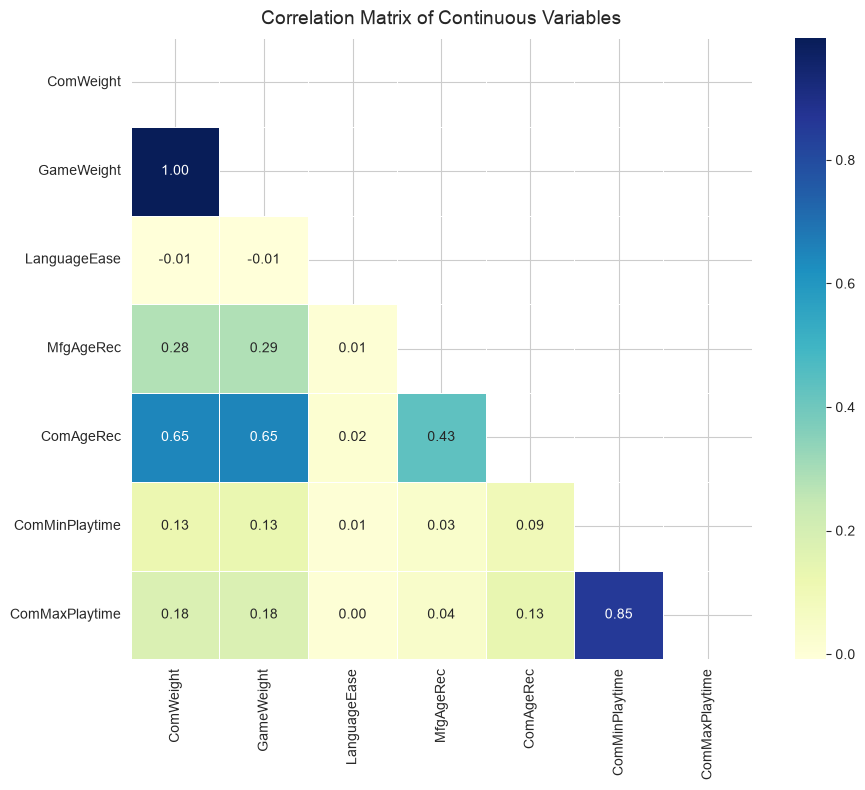

In [66]:
# matrix heatmap of correlation between continuous variables
numeric_df = df.select_dtypes(include=[np.number])
cols_to_insert = ['ComWeight', 'GameWeight', 'LanguageEase', 'MfgAgeRec',
                  'ComAgeRec','ComMinPlaytime', 'ComMaxPlaytime']
numeric_df = numeric_df[cols_to_insert]
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar=True,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 10}
)
plt.title("Correlation Matrix of Continuous Variables", fontsize=14, pad=10)
plt.tight_layout()
plt.show()

In [67]:
df.head()

,BGGId,Name,Description,YearPublished,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,...,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating,Total_Categories
0,140386,Assassin's Creed: Arena,game description publisherin assassins creed a...,2014,1.8333,2.0512,2,4,8.0,213.0,...,0,0,0,0,0,0,0,0,Low,0
1,344114,Bag of Chips,bag chip party game face crucial choice score ...,2021,1.0000,1.2256,2,5,8.0,36.0,...,0,0,0,0,0,0,0,0,Medium,0
2,319196,Gùgōng: Deluxe Big Box,big box contain component gugravegng deluxe ed...,2020,3.6667,3.8190,1,5,NaN,NaN,...,0,0,0,0,0,0,0,0,High,0
3,11404,LetterFlip,publisherthe reveal game secret wordsletterfli...,2004,1.3077,1.4216,2,2,7.0,NaN,...,0,0,0,0,0,0,0,0,Low,0
4,281020,Treasures of Cibola,rescue mayan treasure easy task ...,2019,1.5000,1.6230,2,4,NaN,7.0,...,0,0,0,0,0,0,0,0,Medium,0


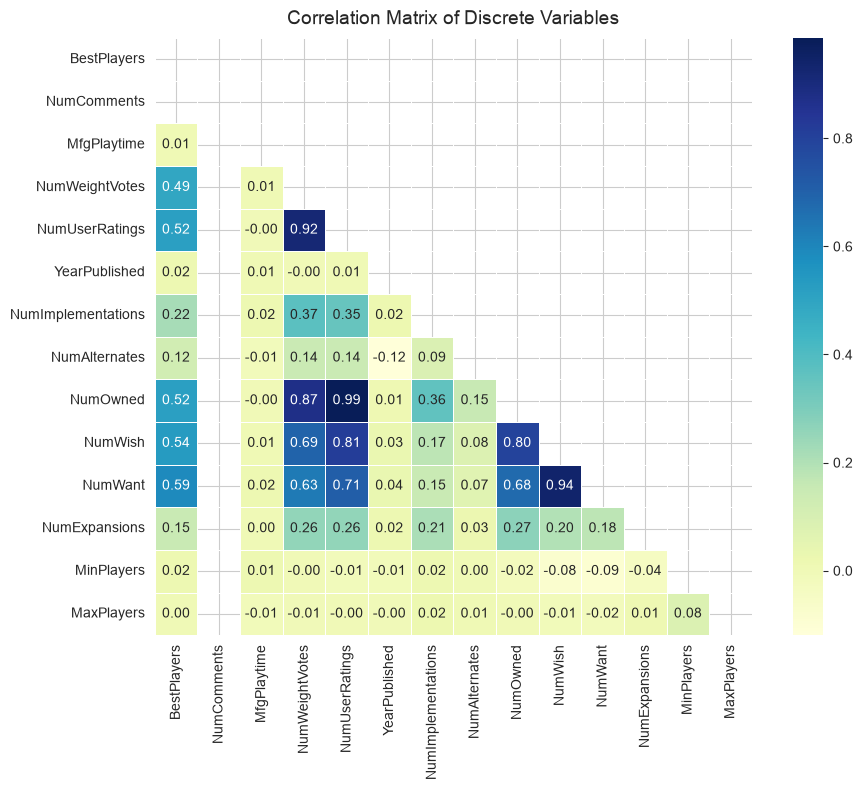

In [68]:
# matrix heatmap of correlation between discrete variables
numeric_df = df.select_dtypes(include=[np.number])
cols_to_insert = ['BestPlayers', 'NumComments', 'MfgPlaytime',
                  'NumWeightVotes','NumUserRatings', 'YearPublished','NumImplementations',
                  'NumAlternates','NumOwned', 'NumWish', 'NumWant','NumExpansions','MinPlayers',
                  'MaxPlayers']

numeric_df = numeric_df[cols_to_insert]
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar=True,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 10}
)
plt.title("Correlation Matrix of Discrete Variables", fontsize=14, pad=10)
plt.tight_layout()
plt.show()

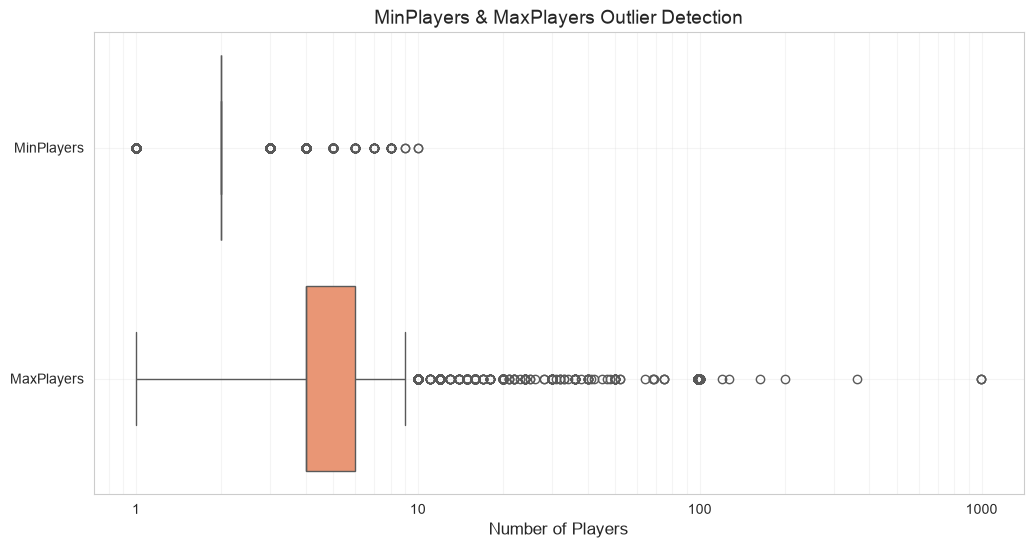

In [69]:
plt.figure(figsize=(12, 6))

# 1. Create the horizontal boxplot
sns.boxplot(data=df[['MinPlayers', 'MaxPlayers']], orient='h', palette='Set2')

# 2. Apply a logarithmic scale to the X-axis
plt.xscale('log')

# 3. Format numbers to improve readability (e.g., 10, 100 instead of 10^1, 10^2)
plt.gca().xaxis.set_major_formatter(ScalarFormatter())

plt.title('MinPlayers & MaxPlayers Outlier Detection', fontsize=14)
plt.xlabel('Number of Players', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.2)  # Add a light grid

plt.show()

## Summary & Next Steps

### Key data quality issues found
- **Duplicates**: no duplicate `BGGId`; 404 duplicate `Name` values (different editions of the same game, expected); 21 groups of games share an identical `Description` (likely templated/boilerplate text — worth checking before using `Description` as a feature).
- **Missing values**: `Family` (69.6%), `LanguageEase` (26.9%), `ComAgeRec` (25.2%) are the columns most affected. `ImagePath` and `Description` have negligible missingness.
- **Category coverage**: 54.1% of games have no `Cat:*` label at all, and 4.7% have more than one — the category features are sparse and not mutually exclusive, which affects both visualization choices (see pie chart note) and any modeling that treats them as one-hot.
- **Logical inconsistencies**: `MinPlayers > MaxPlayers` and `ComMinPlaytime > ComMaxPlaytime` occur mainly when the max value is recorded as 0 (placeholder for "unknown"/"unbounded"), not genuine contradictions. `Kickstarted` games published before 2009 (83 cases) are true data errors, since Kickstarter didn't exist yet.
- **Zero-as-missing pattern**: `GameWeight = 0` corresponds exactly to `NumWeightVotes = 0` — confirms these zeros are missing values in disguise, not legitimate low-complexity scores.
- **Outliers**: a handful of extreme `YearPublished` values (< 1900, including clearly invalid entries) and a few extreme playtimes (e.g. one game recorded at 60,000 minutes, consistent with an official "unlimited duration" title) need explicit handling rather than blanket removal.

### Implications for Data Preparation
- Treat `GameWeight`/`ComWeight` zeros, `MaxPlayers`/`ComMaxPlaytime` zeros, and `BestPlayers`/`GoodPlayers` (>90% empty) as missing rather than valid measurements.
- The Mann-Whitney tests (with FDR correction) show that `GameWeight`, `ComAgeRec`, `ComMinPlaytime`/`ComMaxPlaytime`, and `LanguageEase` vary significantly across most `Cat:*` categories — imputation for these variables should be done **per category** (median/mode within group) rather than with a single global value.
- `Family` is too sparse (69.6% missing) to impute reliably; it's better suited to being dropped, or grouped into a small number of top categories plus "Other", than to imputation.
- `NumWant` and `NumWish` are highly correlated (r = 0.94), as are `GameWeight` and `ComWeight` (r = 0.997) — one of each pair could be dropped to reduce redundancy in later modeling steps.
- `YearPublished` before 1900 and the 83 pre-2009 `Kickstarted` anomalies should be corrected or removed before modeling.

### Open questions for the next notebook
- How should the 54% of games with no category label be handled — left as "uncategorized", or reassigned using text/family information?
- Should skewed count features (`NumOwned`, `NumWant`, `NumWish`, `NumUserRatings`) be log-transformed before modeling, given the skewness observed here?
